In [1]:
import pandas as pd

# 1. Cargar la base
df = pd.read_csv(
    "C:/Users/loloa/OneDrive/Escritorio/facu/Ciencia de datos/trabajo_final/TP-Final-Ciencia-de-Datos/Base Aprender Estudiantes 6 Grado Primaria 2023 (3).csv",
    sep=";",       # si no funciona con "," probá con ";"
    encoding="latin1"  # si no funciona, probá "utf-8"
)

# 2. Dimensiones de la base
print("Dimensiones (filas, columnas):", df.shape)

# 3. Primeras filas (para mostrar ejemplos)
print(df.head())

# 4. Información general: tipos de variables y nulos
print("\nInformación de las columnas:")
print(df.info())

# 5. Resumen estadístico de las variables numéricas
print("\nResumen estadístico (solo numéricas):")
print(df.describe())

# 6. Ver algunas variables categóricas (ejemplo con 'provincia' o 'genero')
if 'provincia' in df.columns:
    print("\nDistribución por provincia:")
    print(df['provincia'].value_counts().head(10))

if 'genero' in df.columns:
    print("\nDistribución por género:")
    print(df['genero'].value_counts())


Dimensiones (filas, columnas): (642006, 206)
           ï»¿ID1  jurisdiccion  seccion  idalumno  sector  ambito ap01 ap02  \
0  20004002000400            50        1    247287       1       2    2    1   
1  20004002000400            50        2    247266       1       2    3    9   
2  20004002000400            50        1    247288       1       2    3    9   
3  20004002000400            50        1    247289       1       2    2    1   
4  20004002000400            50        1    247290       1       2    2   12   

  ap03 ap04  ...   mpuntaje  NSE_puntaje NSE_nivel edadA_junio2023 migracion  \
0    1    1  ...  466,75851  ,0057786424         2               2         2   
1    1    1  ...  455,46713   -,36903167         2               2         2   
2    1    1  ...  356,53931   -,50107211         2               2         2   
3    1    1  ...  449,15985    ,59687847         2               2         2   
4    1    1  ...  444,71057    ,92589754         2               2        

## Proceso de limpieza y tratamiento de missing values

In [2]:
import numpy as np
import pandas as pd

# Convertir todas las columnas a numérico si es posible
df_numeric = df.apply(pd.to_numeric, errors='coerce')

# Ahora reemplazar códigos negativos que representan NA
df_replaced = df_numeric.replace([-9, -8, -6], np.nan)

# Revisar
print(df_replaced.head())
print(df_replaced.isnull().sum())


# Contar valores faltantes por variable
print(df_replaced.isnull().sum())

# Porcentaje de faltantes por variable
missing_percent = df_replaced.isnull().mean() * 100
print(missing_percent.sort_values(ascending=False))


           ï»¿ID1  jurisdiccion  seccion  idalumno  sector  ambito  ap01  \
0  20004002000400            50        1    247287       1       2   2.0   
1  20004002000400            50        2    247266       1       2   3.0   
2  20004002000400            50        1    247288       1       2   3.0   
3  20004002000400            50        1    247289       1       2   2.0   
4  20004002000400            50        1    247290       1       2   2.0   

   ap02  ap03  ap04  ...  mpuntaje  NSE_puntaje  NSE_nivel  edadA_junio2023  \
0   1.0   1.0   1.0  ...       NaN          NaN          2              2.0   
1   9.0   1.0   1.0  ...       NaN          NaN          2              2.0   
2   9.0   1.0   1.0  ...       NaN          NaN          2              2.0   
3   1.0   1.0   1.0  ...       NaN          NaN          2              2.0   
4  12.0   1.0   1.0  ...       NaN          NaN          2              2.0   

   migracion  sobreedad  Nivel_Ed_Madre  Nivel_Ed_Padre  region  cli

In [3]:
import pandas as pd

# Lista de variables de interés
vars_interes = [
    "idalumno", "jurisdiccion", "sector", "ambito", "ap01", "ap06a", "ap06b", "ap06c", "ap06d", "ap06e",
    "ap07a", "ap07b",
    "ap10", 'ldesemp', 'mdesemp', 'Nivel_Ed_Madre','Nivel_Ed_Padre', "NSE_nivel"
]


# Construir tabla de resumen
tabla_nas = pd.DataFrame({
    "Cantidad_NA": df_replaced[vars_interes].isnull().sum(),
    "Porcentaje_NA": df_replaced[vars_interes].isnull().mean() * 100
})

# Ordenar por porcentaje de NA descendente
tabla_nas = tabla_nas.sort_values("Porcentaje_NA", ascending=False)

print(tabla_nas)


                Cantidad_NA  Porcentaje_NA
ap07b                138957      21.644190
ap06b                138558      21.582041
ap06e                134261      20.912733
ap06d                131596      20.497628
ap06a                 91555      14.260770
ap06c                 89169      13.889123
ap07a                 54575       8.500699
mdesemp               46344       7.218624
ldesemp               38413       5.983277
ap10                  28103       4.377373
ap01                  28103       4.377373
Nivel_Ed_Padre        21917       3.413831
Nivel_Ed_Madre        20490       3.191559
idalumno                  0       0.000000
jurisdiccion              0       0.000000
sector                    0       0.000000
ambito                    0       0.000000
NSE_nivel                 0       0.000000


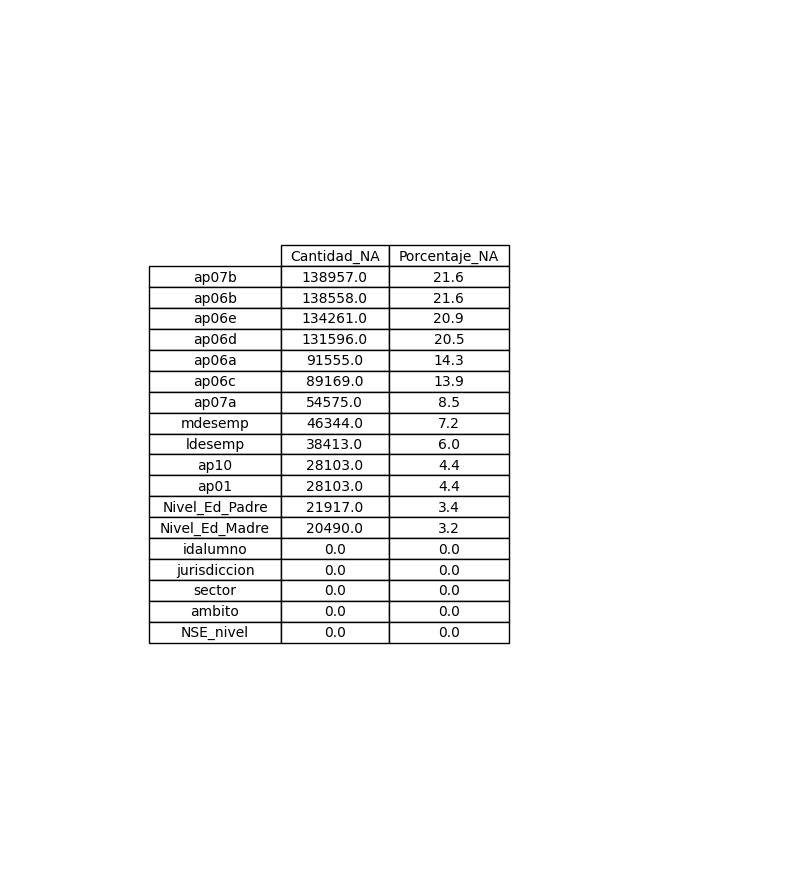

In [4]:
import matplotlib.pyplot as plt

# Redondear los valores a 1 decimal
tabla_nas_1dec = tabla_nas.round(1)

# Crear figura
fig, ax = plt.subplots(figsize=(8, len(tabla_nas_1dec)*0.5))
ax.axis('off')  # quitar ejes

# Dibujar la tabla
tbl = ax.table(cellText=tabla_nas_1dec.values,
               colLabels=tabla_nas_1dec.columns,
               rowLabels=tabla_nas_1dec.index,
               cellLoc='center',
               rowLoc='center',
               loc='center')

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.auto_set_column_width(col=list(range(len(tabla_nas_1dec.columns))))

# Guardar como imagen
plt.tight_layout()
#plt.savefig("tabla_nas_1decimal.png", dpi=300)
plt.show()

In [5]:
#Eliminar filas con missing
df_clean = df.dropna()
print(df_clean.shape)

(642006, 206)


## HEATMAP

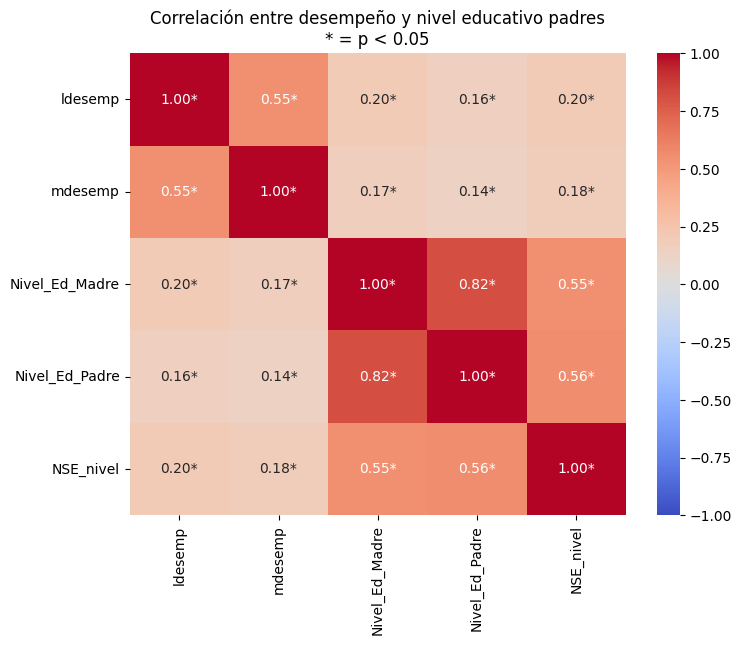

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

cols = ['ldesemp', 'mdesemp', 'Nivel_Ed_Madre', 'Nivel_Ed_Padre', "NSE_nivel"]
df_sub = df_clean[cols].apply(pd.to_numeric, errors='coerce')

n = len(cols)
corr_matrix = np.zeros((n, n))
pval_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        x = df_sub[cols[i]].dropna()
        y = df_sub[cols[j]].dropna()
        # Solo usar filas donde ambos no son NA
        valid = pd.concat([x, y], axis=1).dropna()
        if len(valid) > 1:
            r, p = pearsonr(valid.iloc[:,0], valid.iloc[:,1])
            corr_matrix[i,j] = r
            pval_matrix[i,j] = p
        else:
            corr_matrix[i,j] = np.nan
            pval_matrix[i,j] = np.nan

# Crear DataFrames a partir de las matrices
corr_df = pd.DataFrame(corr_matrix, index=cols, columns=cols)
pval_df = pd.DataFrame(pval_matrix, index=cols, columns=cols)

# Crear anotaciones con significancia
annot = corr_df.copy().astype(str)
for i in cols:
    for j in cols:
        if pd.notnull(corr_df.loc[i,j]):
            sig = "*" if pval_df.loc[i,j] < 0.05 else ""
            annot.loc[i,j] = f"{corr_df.loc[i,j]:.2f}{sig}"
        else:
            annot.loc[i,j] = ""

# Graficar heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_df, annot=annot, fmt="", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación entre desempeño y nivel educativo padres\n* = p < 0.05")
plt.show()


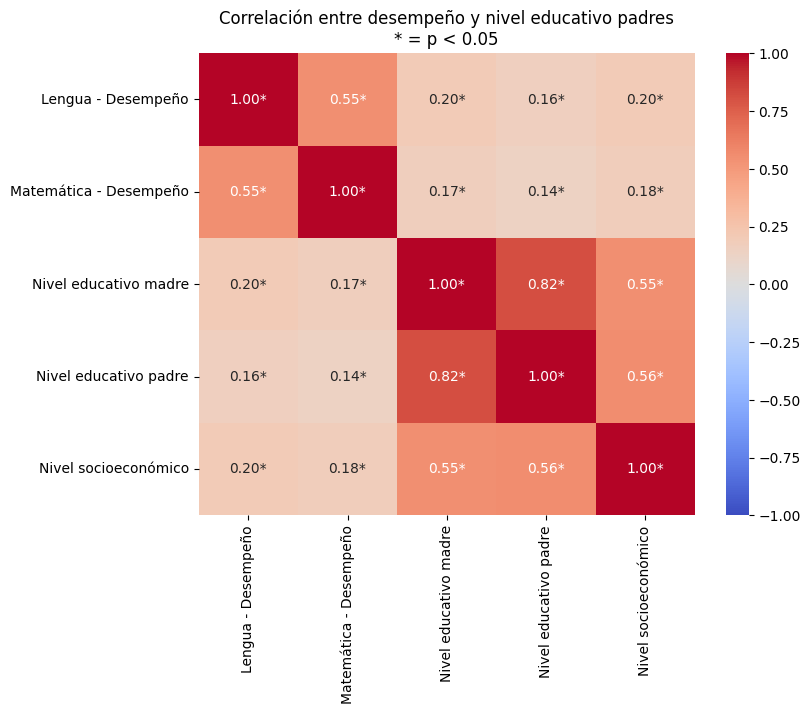

In [7]:
# Diccionario con nombres más claros
rename_dict = {
    "ldesemp": "Lengua - Desempeño",
    "mdesemp": "Matemática - Desempeño",
    "Nivel_Ed_Madre": "Nivel educativo madre",
    "Nivel_Ed_Padre": "Nivel educativo padre",
    "NSE_nivel": "Nivel socioeconómico"
}

# Renombrar índices y columnas en corr_df, pval_df y annot
corr_df = corr_df.rename(index=rename_dict, columns=rename_dict)
pval_df = pval_df.rename(index=rename_dict, columns=rename_dict)
annot   = annot.rename(index=rename_dict, columns=rename_dict)

# Graficar
plt.figure(figsize=(8,6))
sns.heatmap(corr_df, annot=annot, fmt="", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación entre desempeño y nivel educativo padres\n* = p < 0.05")
plt.show()


## Veamos el tipo de respuesta de las demás variables

In [8]:
import pandas as pd

# Variables de interés
vars_tareas = ["ap01", "ap06a", "ap06b", "ap06c", "ap06d", "ap06e",
               "ap07a", "ap07b"]

# Diccionario para reemplazar códigos por texto (opcional)
codigos = {
    1: "No realicé esta tarea",
    2: "Algunos días",
    3: "De lunes a viernes",
    4: "Todos los días"
}

# Reemplazar códigos por texto (opcional, para la tabla)
df_respuestas = df_replaced[vars_tareas].replace(codigos)

# Crear tabla de frecuencias por variable
for var in vars_tareas:
    freq = df_respuestas[var].value_counts(dropna=False)  # incluir NAs si los hay
    perc = df_respuestas[var].value_counts(normalize=True, dropna=False) * 100
    resumen = pd.DataFrame({"Frecuencia": freq, "Porcentaje": perc.round(2)})
    print(f"\nVariable: {var}")
    print(resumen)



Variable: ap01
                       Frecuencia  Porcentaje
ap01                                         
Algunos días               421390       65.64
De lunes a viernes         172468       26.86
NaN                         28103        4.38
Todos los días              14678        2.29
5.0                          3513        0.55
No realicé esta tarea        1854        0.29

Variable: ap06a
                       Frecuencia  Porcentaje
ap06a                                        
No realicé esta tarea      257026       40.03
Algunos días               169083       26.34
Todos los días             106208       16.54
NaN                         91555       14.26
De lunes a viernes          18134        2.82

Variable: ap06b
                       Frecuencia  Porcentaje
ap06b                                        
No realicé esta tarea      404025       62.93
NaN                        138558       21.58
Algunos días                67225       10.47
Todos los días              20

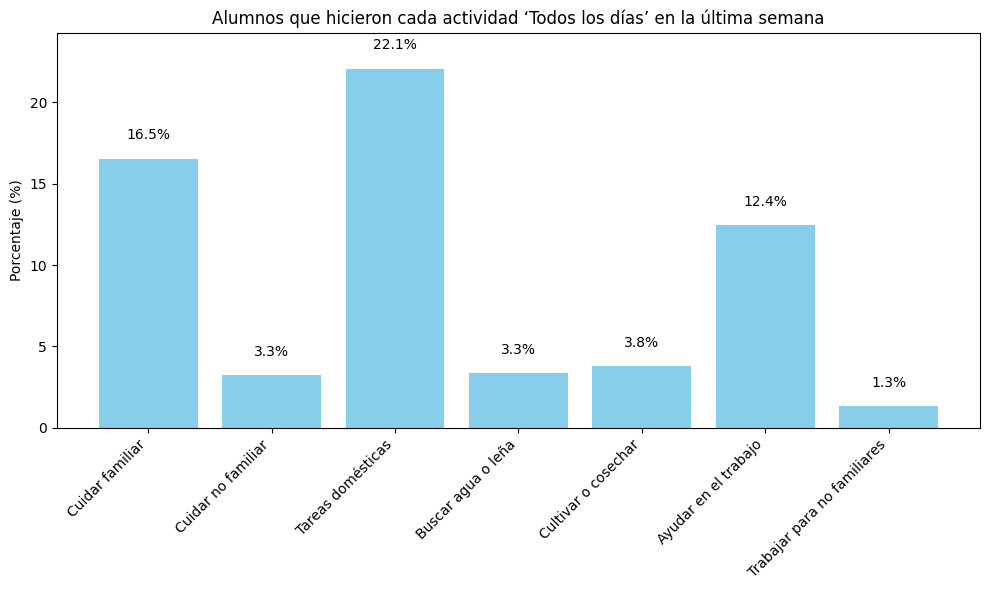

In [9]:
import matplotlib.pyplot as plt

# Variables de interés
vars_tareas = ["ap06a", "ap06b", "ap06c", "ap06d", "ap06e",
               "ap07a", "ap07b"]

# Diccionario para nombres más ilustrativos
nombres = {
    "ap06a": "Cuidar familiar",
    "ap06b": "Cuidar no familiar",
    "ap06c": "Tareas domésticas",
    "ap06d": "Buscar agua o leña",
    "ap06e": "Cultivar o cosechar",
    "ap07a": "Ayudar en el trabajo",
    "ap07b": "Trabajar para no familiares"
}

# Seleccionar solo la columna de interés
df_respuestas = df_replaced[vars_tareas]

# Calcular el porcentaje que respondió 4 ("Todos los días") en cada variable
porc_todos_dias = df_respuestas.apply(lambda x: (x == 4).mean() * 100)

# Renombrar las variables para el gráfico
porc_todos_dias.index = [nombres[i] for i in porc_todos_dias.index]

# Gráfico de barras
plt.figure(figsize=(10,6))
bars = plt.bar(porc_todos_dias.index, porc_todos_dias, color="skyblue")

# Limitar eje y un poco por encima del máximo
plt.ylim(0, max(porc_todos_dias)*1.1)

# Mostrar porcentaje encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', va='bottom')

plt.ylabel("Porcentaje (%)")
plt.title("Alumnos que hicieron cada actividad ‘Todos los días’ en la última semana")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


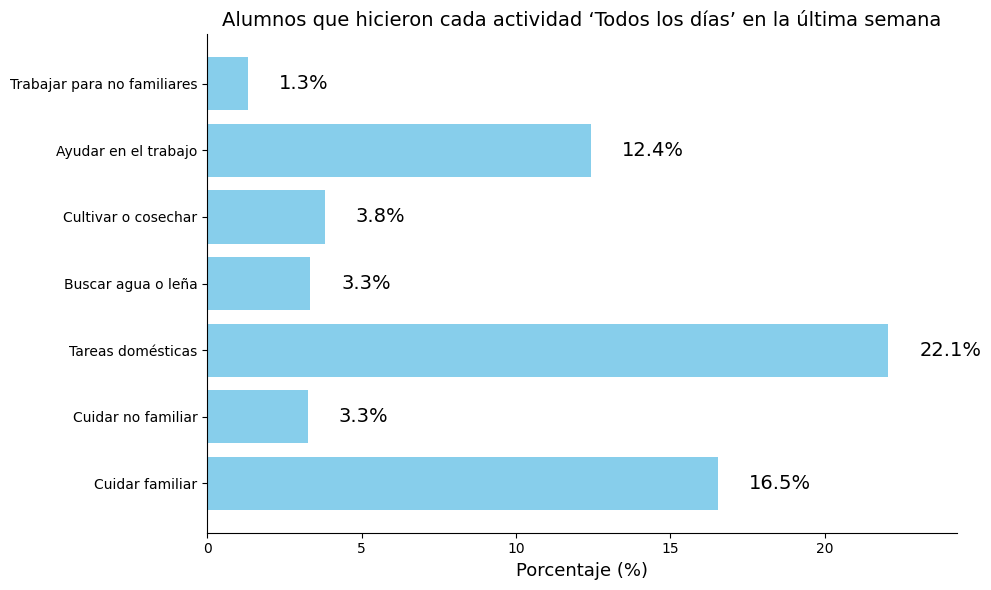

In [10]:
import matplotlib.pyplot as plt

# Variables de interés
vars_tareas = ["ap06a", "ap06b", "ap06c", "ap06d", "ap06e",
               "ap07a", "ap07b"]

# Diccionario para nombres más ilustrativos
nombres = {
    "ap06a": "Cuidar familiar",
    "ap06b": "Cuidar no familiar",
    "ap06c": "Tareas domésticas",
    "ap06d": "Buscar agua o leña",
    "ap06e": "Cultivar o cosechar",
    "ap07a": "Ayudar en el trabajo",
    "ap07b": "Trabajar para no familiares"
}

# Seleccionar solo la columna de interés
df_respuestas = df_replaced[vars_tareas]
# Calcular el porcentaje que respondió 4 ("Todos los días") en cada variable
porc_todos_dias = df_respuestas.apply(lambda x: (x == 4).mean() * 100)

# Renombrar las variables para el gráfico
porc_todos_dias.index = [nombres[i] for i in porc_todos_dias.index]

# Gráfico de barras horizontales
plt.figure(figsize=(10,6))
bars = plt.barh(porc_todos_dias.index, porc_todos_dias, color="skyblue")

# Limitar eje x un poco por encima del máximo
plt.xlim(0, max(porc_todos_dias)*1.1)

# Mostrar porcentaje a la derecha de cada barra (más grande)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%', va='center', fontsize=14, color="black")

# Quitar el recuadro (spines)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.xlabel("Porcentaje (%)", fontsize=13)
plt.title("Alumnos que hicieron cada actividad ‘Todos los días’ en la última semana", fontsize=14)
plt.tight_layout()
plt.show()


In [11]:
print(df["ap24a"].head())

0     0
1    -9
2    -9
3     0
4     1
Name: ap24a, dtype: object


  ap24a ap24b ap24c ap24d ap24e ap24f ap24g ap24h ap24i ap24j ap24k
0   0.0   0.0   1.0   1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
1  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>
2  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>
3   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  <NA>   0.0   0.0
4   1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0


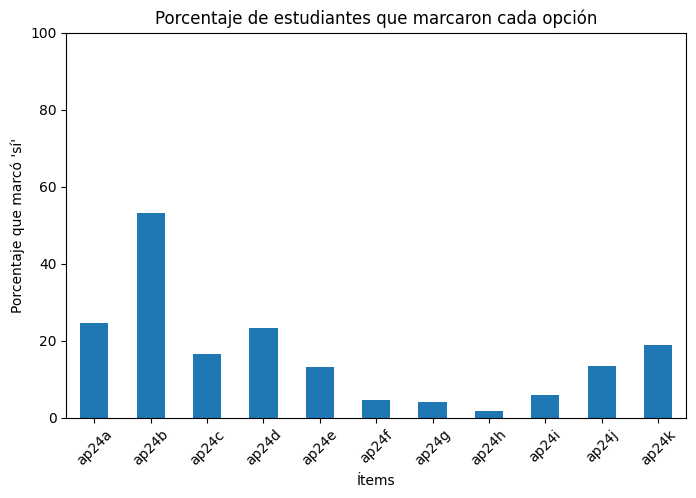

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

vars_ap = ["ap24a","ap24b","ap24c","ap24d","ap24e",
           "ap24f","ap24g","ap24h","ap24i","ap24j","ap24k"]

# 1. Convertir a numérico y reemplazar errores por NaN
df[vars_ap] = df[vars_ap].apply(pd.to_numeric, errors='coerce')

# 2. Reemplazar códigos de no respuesta por NaN
df[vars_ap] = df[vars_ap].replace([-9, -8, -7], pd.NA)

# 3. Revisar la limpieza
print(df[vars_ap].head())

# 4. Calcular porcentaje de "Todos los días" (suponiendo que es 1)
porcentajes = df[vars_ap].apply(lambda x: (x==1).mean()*100)

# Crear gráfico de barras
plt.figure(figsize=(8,5))
porcentajes.plot(kind="bar")

# Estética
plt.ylabel("Porcentaje que marcó 'sí'")
plt.xlabel("Ítems")
plt.title("Porcentaje de estudiantes que marcaron cada opción")
plt.ylim(0, 100)  # eje Y en porcentaje
plt.xticks(rotation=45)

plt.show()


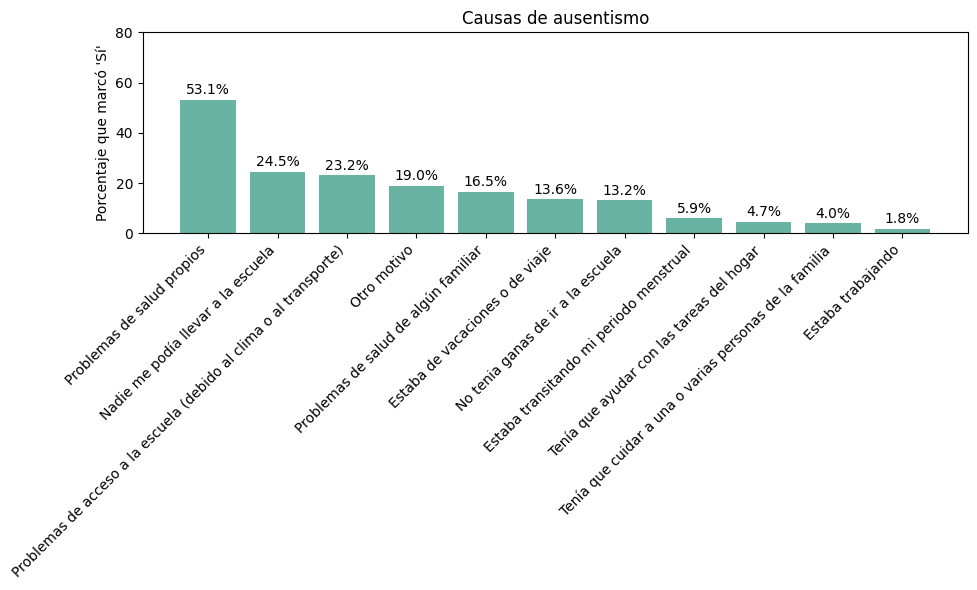

In [13]:
import matplotlib.pyplot as plt

# Etiquetas descriptivas
labels = [
    "Nadie me podía llevar a la escuela",
    "Problemas de salud propios",
    "Problemas de salud de algún familiar",
    "Problemas de acceso a la escuela (debido al clima o al transporte)",
    "No tenia ganas de ir a la escuela",
    "Tenía que ayudar con las tareas del hogar",
    "Tenía que cuidar a una o varias personas de la familia",
    "Estaba trabajando",
    "Estaba transitando mi periodo menstrual",
    "Estaba de vacaciones o de viaje",
    "Otro motivo"
]

# Crear un DataFrame temporal para ordenar
df_graf = pd.DataFrame({
    "Actividad": labels,
    "Porcentaje": porcentajes.values
})

# Ordenar de mayor a menor
df_graf = df_graf.sort_values(by="Porcentaje", ascending=False)

# Color de las barras
color_barras = "#69b3a2"

# Crear gráfico de barras vertical
plt.figure(figsize=(10,6))
bars = plt.bar(df_graf["Actividad"], df_graf["Porcentaje"], color=color_barras)

# Limitar eje Y a 80
plt.ylim(0, 80)

# Mostrar porcentaje encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.1f}%", ha='center', va='bottom')

# Estética
plt.ylabel("Porcentaje que marcó 'Sí'")
plt.title("Causas de ausentismo")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

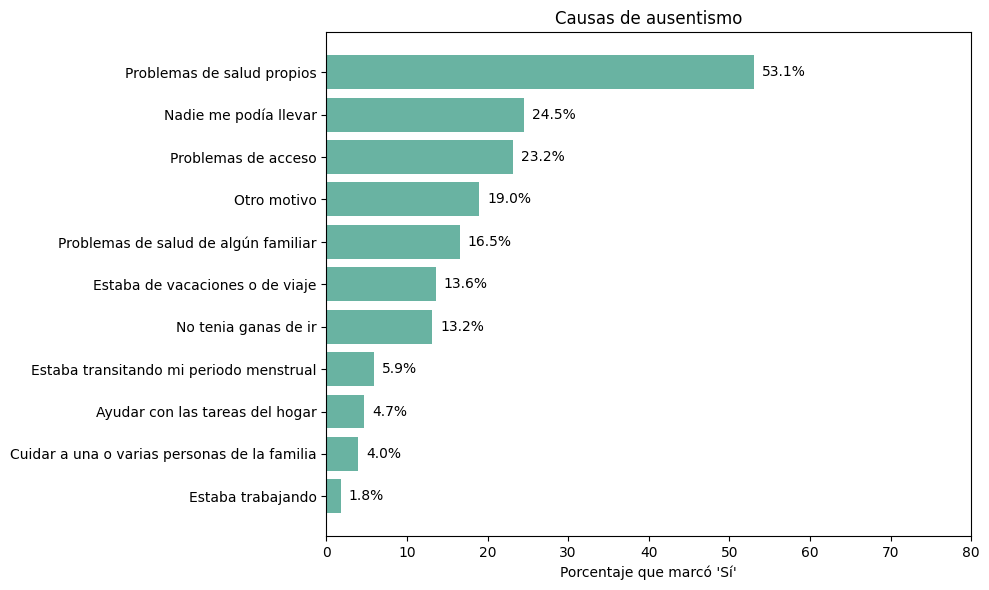

In [14]:
import matplotlib.pyplot as plt

# Etiquetas descriptivas
labels = [
    "Nadie me podía llevar",
    "Problemas de salud propios",
    "Problemas de salud de algún familiar",
    "Problemas de acceso",
    "No tenia ganas de ir",
    "Ayudar con las tareas del hogar",
    "Cuidar a una o varias personas de la familia",
    "Estaba trabajando",
    "Estaba transitando mi periodo menstrual",
    "Estaba de vacaciones o de viaje",
    "Otro motivo"
]

# Crear DataFrame temporal para ordenar
df_graf = pd.DataFrame({
    "Actividad": labels,
    "Porcentaje": porcentajes.values
})

# Ordenar de mayor a menor
df_graf = df_graf.sort_values(by="Porcentaje", ascending=True)  # ascending=True para que la barra más grande quede arriba

# Color de las barras
color_barras = "#69b3a2"

# Crear gráfico de barras horizontal
plt.figure(figsize=(10,6))
bars = plt.barh(df_graf["Actividad"], df_graf["Porcentaje"], color=color_barras)

# Limitar eje X a 80
plt.xlim(0, 80)

# Mostrar porcentaje al final de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f"{width:.1f}%", ha='left', va='center')

# Estética
plt.xlabel("Porcentaje que marcó 'Sí'")
plt.title("Causas de ausentismo")
plt.tight_layout()
plt.show()

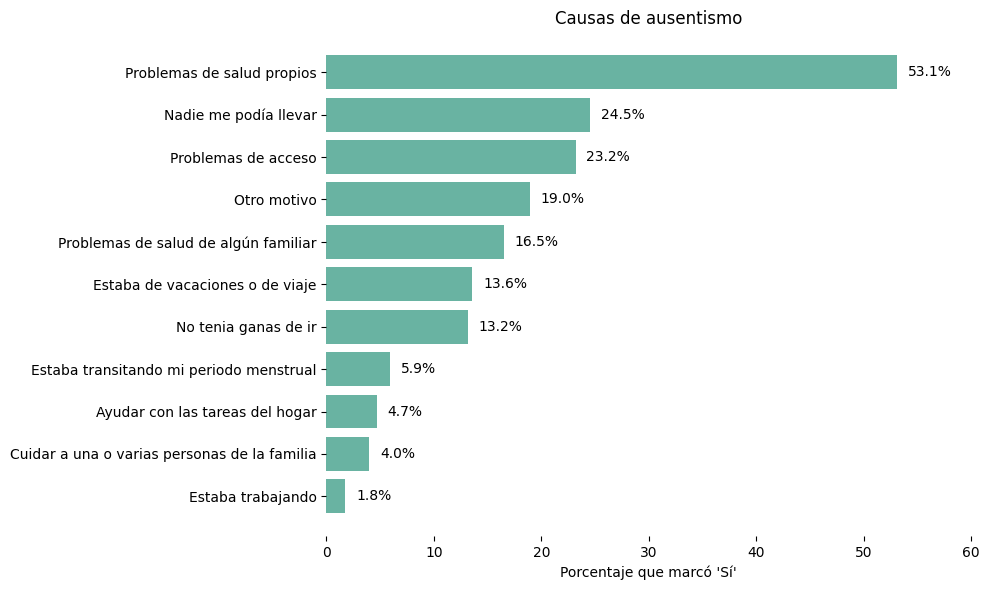

In [15]:
import matplotlib.pyplot as plt

# Crear gráfico de barras horizontal
plt.figure(figsize=(10,6))
bars = plt.barh(df_graf["Actividad"], df_graf["Porcentaje"], color=color_barras)

# Limitar eje X a 80
plt.xlim(0, 60)

# Mostrar porcentaje al final de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f"{width:.1f}%", ha='left', va='center')

# Estética
plt.xlabel("Porcentaje que marcó 'Sí'")
plt.title("Causas de ausentismo")

# Quitar el marco (spines)
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()


In [16]:
# Reemplazar coma por punto y convertir a float
import pandas as pd
import numpy as np

# Reemplazar espacios vacíos por NaN
df["mpuntaje"] = df["mpuntaje"].replace(" ", np.nan)

# Convertir de string con coma a float
df["mpuntaje"] = df["mpuntaje"].str.replace(",", ".").astype(float)


In [17]:
# Reemplazar coma por punto y convertir a float
import pandas as pd
import numpy as np

# Reemplazar espacios vacíos por NaN
df["lpuntaje"] = df["lpuntaje"].replace(" ", np.nan)

# Convertir de string con coma a float
df["lpuntaje"] = df["lpuntaje"].str.replace(",", ".").astype(float)


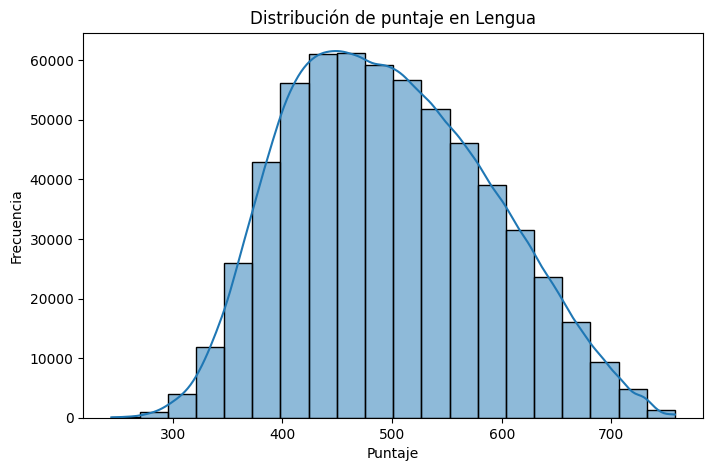

In [18]:
#mmm se ve raro...

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data=df, x="lpuntaje", bins=20, kde=True)
plt.title("Distribución de puntaje en Lengua")
plt.xlabel("Puntaje")
plt.ylabel("Frecuencia")
plt.show()


In [19]:
import pandas as pd

tabla = pd.crosstab(df_replaced["NSE_nivel"], df_replaced["ldesemp"], normalize="index") * 100
print(tabla)

ldesemp          1.0        2.0        3.0        4.0
NSE_nivel                                            
1          19.151620  30.111272  34.364468  16.372639
2          11.731175  21.911337  38.697209  27.660279
3           5.468635  11.586628  33.335596  49.609141


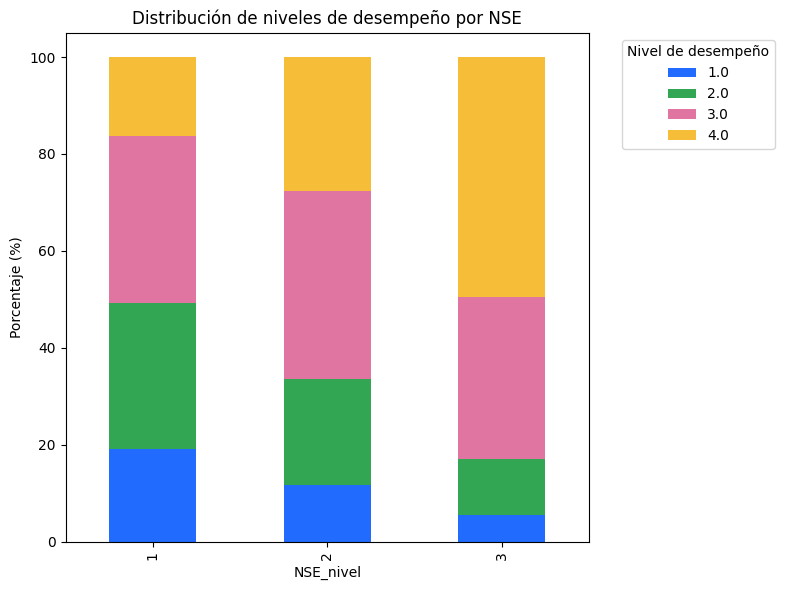

In [20]:
import matplotlib.pyplot as plt

# calculamos porcentajes con crosstab (más limpio)
tabla = pd.crosstab(df_replaced["NSE_nivel"], df_replaced["ldesemp"], normalize="index") * 100

# asegurar orden de columnas (niveles 1 a 4)
tabla = tabla[[1,2,3,4]]

# Colores pasteles
colores_pastel = ["#216cff", "#33a654", "#e075a1", "#f6be38"]

# gráfico
tabla.plot(kind="bar", stacked=True, figsize=(8,6), color=colores_pastel)

plt.ylabel("Porcentaje (%)")
plt.title("Distribución de niveles de desempeño por NSE")
plt.legend(title="Nivel de desempeño", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

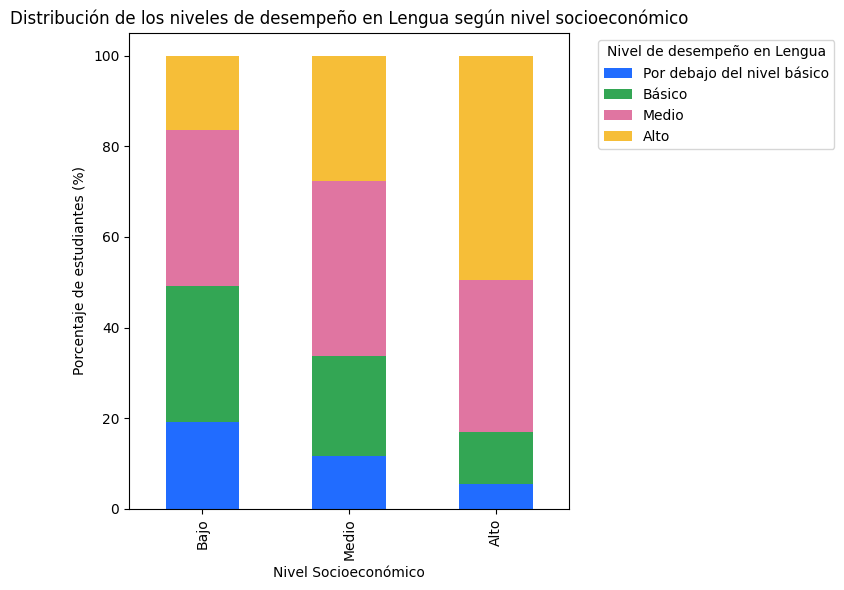

In [21]:
import matplotlib.pyplot as plt

# calculamos porcentajes con crosstab (más limpio)
tabla = pd.crosstab(df_replaced["NSE_nivel"], df_replaced["ldesemp"], normalize="index") * 100

# asegurar orden de columnas (niveles 1 a 4 en desempeño)
tabla = tabla[[1,2,3,4]]

# renombrar índices de NSE
tabla = tabla.rename(index={1: "Bajo", 2: "Medio", 3: "Alto"})

# Colores pasteles
colores_pastel = ["#216cff", "#33a654", "#e075a1", "#f6be38"]

# gráfico
ax = tabla.plot(kind="bar", stacked=True, figsize=(8,6), color=colores_pastel)

plt.xlabel("Nivel Socioeconómico")
plt.ylabel("Porcentaje de estudiantes (%)")
plt.title("Distribución de los niveles de desempeño en Lengua según nivel socioeconómico")
plt.legend(
    title="Nivel de desempeño en Lengua", 
    labels=["Por debajo del nivel básico", "Básico", "Medio", "Alto"], 
    bbox_to_anchor=(1.05,1), 
    loc="upper left"
)
plt.tight_layout()
plt.show()


Candidatas encontradas para sector/gestión: ['sector', 'ambito']
Usando columna de sector: sector


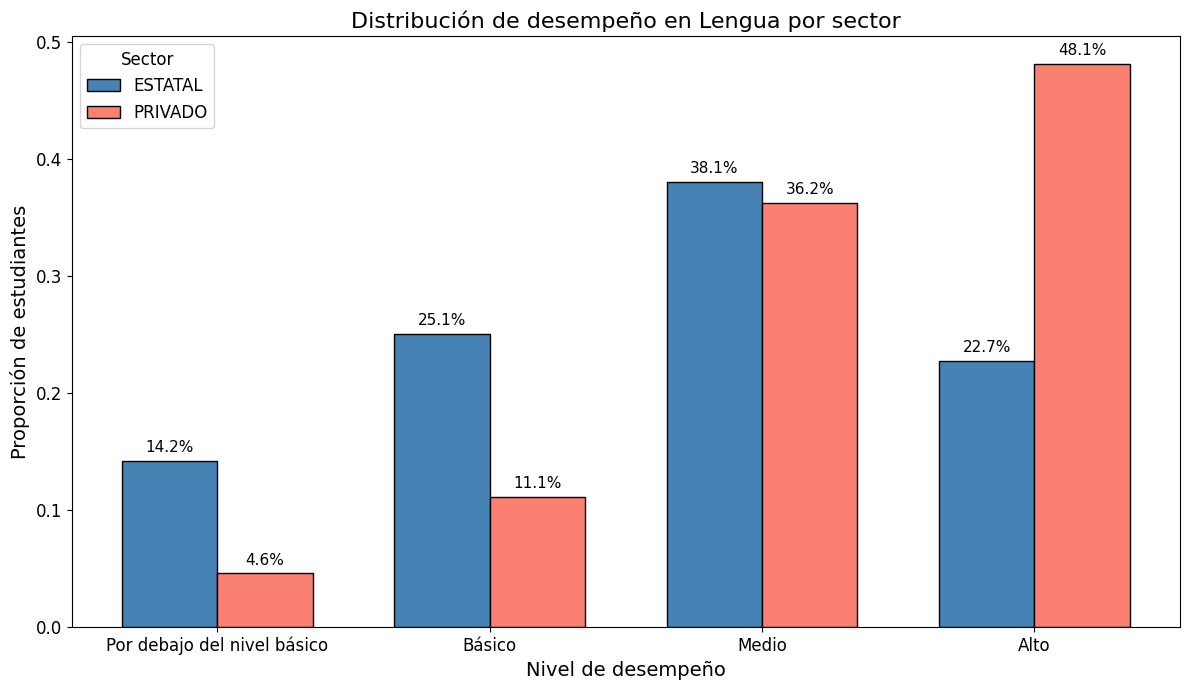

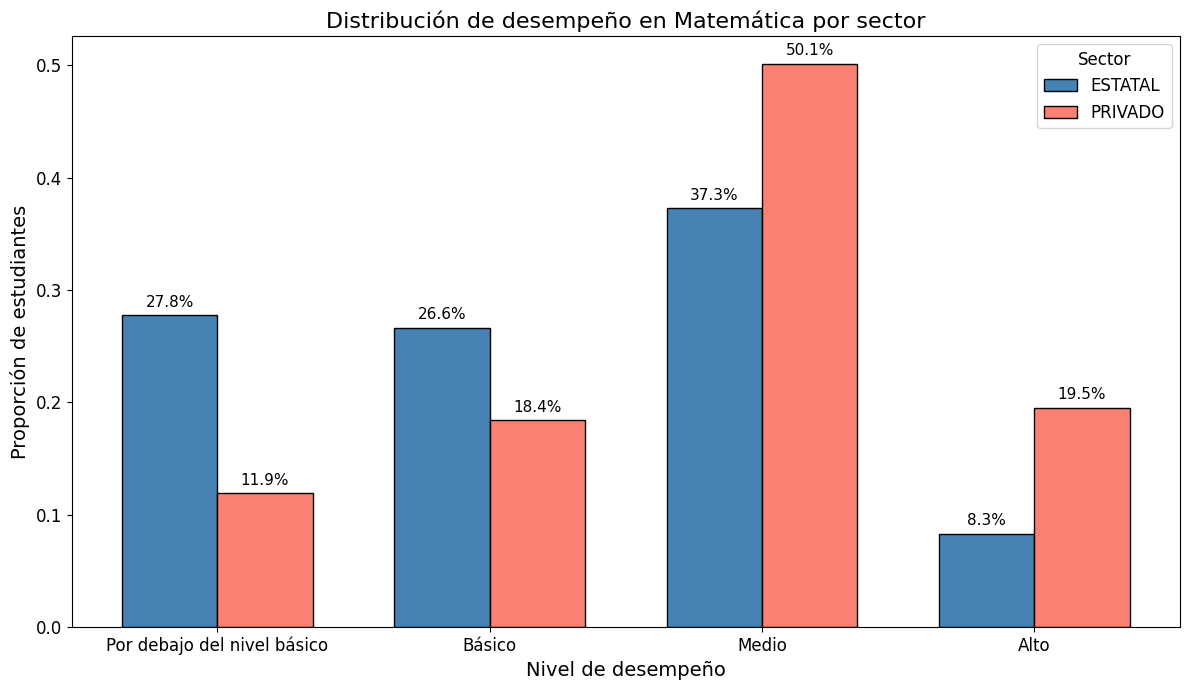

In [22]:
import re, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== Helpers =====
def _norm_txt(s: str) -> str:
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))     # quita acentos
    s = re.sub(r"[^a-z0-9]+", "_", s.lower())                        # a-z0-9 y _
    return s.strip("_")

def find_sector_col(df):
    norm_map = {_norm_txt(c): c for c in df.columns}
    # patrones frecuentes: sector/gestion/ambito/dependencia/tipo_gestion
    pat = re.compile(r"(sector|gestion|tipo_gestion|tipo.*gestion|ambito|dependenc)")
    candidatas = [orig for norm, orig in norm_map.items() if pat.search(norm)]
    # prioridad
    prioridad = ["tipo_gestion","sector","gestion","ambito","dependenc"]
    for key in prioridad:
        for norm, orig in norm_map.items():
            if key in norm:
                return orig, candidatas
    return (candidatas[0] if candidatas else None), candidatas

def limpiar_desempeno(s, niveles=[1,2,3,4]):
    s = s.astype(str).str.strip().replace({"": np.nan})
    s = pd.to_numeric(s, errors="coerce")
    s = s.where(s.isin(niveles))
    return s

def normalizar_sector(s):
    s = s.astype(str).str.strip().str.upper()
    map_vals = {
        "1": "ESTATAL", "PUBLICA": "ESTATAL", "PUBLICO": "ESTATAL", "ESTATAL": "ESTATAL",
        "2": "PRIVADO", "PRIVADA": "PRIVADO", "PRIVADO": "PRIVADO"
    }
    return s.replace(map_vals)

# ===== Detectar columnas =====
col_sector, candidatas = find_sector_col(df_clean)
print("Candidatas encontradas para sector/gestión:", candidatas)
if not col_sector:
    raise ValueError("No encontré columna de sector/gestión. Elegí una de 'candidatas' y asignala a col_sector.")

print("Usando columna de sector:", col_sector)

# Ajustá si tus nombres de desempeño son otros:
col_lengua = "ldesemp"
col_mate   = "mdesemp"
for col in [col_lengua, col_mate]:
    if col not in df_clean.columns:
        raise KeyError(f"No existe la columna '{col}'. Revisa df_clean.columns y ajusta col_lengua/col_mate.")

# ===== Preparar datos =====
niveles = [1,2,3,4]

# ===== Etiquetas personalizadas para niveles de desempeño =====
labels_niveles = {
    1: "Por debajo del nivel básico",
    2: "Básico",
    3: "Medio",
    4: "Alto"
}


tmp = df_clean[[col_sector, col_lengua, col_mate]].copy()
tmp[col_sector] = normalizar_sector(tmp[col_sector])
tmp[col_lengua] = limpiar_desempeno(tmp[col_lengua], niveles)
tmp[col_mate]   = limpiar_desempeno(tmp[col_mate], niveles)

# Función para armar tabla de proporciones por nivel y sector
def tabla_prop(data, col_desemp, col_sector, niveles):
    g = (data.dropna(subset=[col_desemp, col_sector])
            .groupby([col_sector, col_desemp])
            .size()
            .reset_index(name="n"))
    # completar niveles faltantes por sector
    sectores = g[col_sector].unique().tolist()
    full = (pd.MultiIndex.from_product([sectores, niveles], names=[col_sector, col_desemp])
            .to_frame(index=False))
    g = full.merge(g, on=[col_sector, col_desemp], how="left").fillna({"n":0})
    # proporciones dentro de cada sector
    g["prop"] = g.groupby(col_sector)["n"].transform(lambda x: x/x.sum())
    return g

tab_L = tabla_prop(tmp, col_lengua, col_sector, niveles)
tab_M = tabla_prop(tmp, col_mate,   col_sector, niveles)

# ===== Plot: barras agrupadas (Lengua y Matemática por separado) =====
def plot_grouped(tab, titulo):
    sectores = tab[col_sector].unique().tolist()
    colores = {"ESTATAL":"steelblue", "PRIVADO":"salmon"}
    # Si hay otros labels, asignarles colores alternos
    for s in sectores:
        colores.setdefault(s, "gray")

    x = np.arange(len(niveles))  # posiciones 1..4
    width = 0.35 if len(sectores)==2 else 0.8/len(sectores)

    plt.figure(figsize=(12,7))
    for i, sec in enumerate(sectores):
        sub = tab[tab[col_sector]==sec].set_index(col_desemp if (col_desemp:=tab.columns[1]) else "Nivel")
        y = sub.loc[niveles, "prop"].values
        plt.bar(x + i*width - (width*(len(sectores)-1)/2), y, width,
                label=sec, color=colores[sec], edgecolor="black")

        # etiquetas %
        for xi, yi in zip(x + i*width - (width*(len(sectores)-1)/2), y):
            plt.text(xi, yi + 0.005, f"{yi*100:.1f}%", ha="center", va="bottom", fontsize=11)

    plt.title(titulo, fontsize=16)
    plt.xlabel("Nivel de desempeño", fontsize=14)
    plt.ylabel("Proporción de estudiantes", fontsize=14)
    plt.xticks(x, [labels_niveles[n] for n in niveles], fontsize=12, rotation=0, ha="center")
    plt.yticks(fontsize=12)
    plt.legend(title="Sector", fontsize=12, title_fontsize=12)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

plot_grouped(tab_L, "Distribución de desempeño en Lengua por sector")
plot_grouped(tab_M, "Distribución de desempeño en Matemática por sector")

In [23]:
# Diccionario de etiquetas para niveles de desempeño
#labels_niveles = {
#    1: "Por debajo del nivel básico",
#    2: "Básico",
#    3: "Medio",
#     4: "Alto"
#}

#def plot_grouped(tab, titulo):
#    sectores = tab[col_sector].unique().tolist()
#    colores = {"ESTATAL":"steelblue", "PRIVADO":"salmon"}
#    for s in sectores:
#        colores.setdefault(s, "gray")
##
#    x = np.arange(len(niveles))  # posiciones 1..4
#    width = 0.35 if len(sectores)==2 else 0.8/len(sectores)
#
#    plt.figure(figsize=(12,7))
#    for i, sec in enumerate(sectores):
#        sub = tab[tab[col_sector]==sec].set_index(col_desemp if (col_desemp:=tab.columns[1]) else "Nivel")
#        y = sub.loc[niveles, "prop"].values
#        plt.bar(x + i*width - (width*(len(sectores)-1)/2), y, width,
#               label=sec, color=colores[sec], edgecolor="black")
#        # etiquetas %
#        for xi, yi in zip(x + i*width - (width*(len(sectores)-1)/2), y):
#            plt.text(xi, yi + 0.005, f"{yi*100:.1f}%", ha="center", va="bottom", fontsize=11)
#
#plt.title("titulo", fontsize=16)
#plt.xlabel("Nivel de desempeño", fontsize=14)
#plt.ylabel("Proporción de estudiantes", fontsize=14)
#plt.xticks(x, [labels_niveles[n] for n in niveles], fontsize=12, rotation=15, ha="right")
#plt.yticks(fontsize=12)
#plt.legend(title="Sector", fontsize=12, title_fontsize=12)
#plt.grid(False)
#plt.tight_layout()
#plt.show()

#lo comenté xq no me anduvo


Gráficos de barras apiladas mostrando la proporción de estudiantes que perciben discriminación por tipo de motivo y sector escolar.


apA38a: Orientación sexual, identidad o expresión de género.
apA38b: Lugar en el que naciste.
apA38c: Ser de un pueblo indígena u originario.
apA38d: Discapacidad.
apA38e: Religión.
apA38f: Intereses y gustos.
apA38g: Aspectos físicos.
apA38h: Vestimenta.
apA38i: Calificaciones.
apA38j: Situación socioeconómica
apA38k: Otros motivos.

agrupo en otros: ap38b,d,e,f,h,i,k

In [24]:

#aca estoy viendo si se cumple la condicion de que si apA37 == 1, al menos una de las columnas apA38a a apA38k es 1
# Columns to check
columns_to_check = ["apA38a", "apA38b", "apA38c", "apA38d", "apA38e", "apA38f", "apA38g", "apA38h", "apA38i", "apA38j", "apA38k"]

# Filter rows where apA37 == 1
filtered_df = df[df["apA37"] == "1"]

# Check if at least one of the specified columns has a value of 1
condition_met = filtered_df[columns_to_check].eq(1).any(axis=1)

# Calculate percentage of rows where the condition is not met
not_met_percentage = (~condition_met).mean() * 100

print(f"The condition is not met {not_met_percentage:.2f}% of the time.")
#o sea si se cumple, casi siempre

The condition is not met 100.00% of the time.


In [25]:
columns_to_check = ["apA38a", "apA38b", "apA38c", "apA38d", "apA38e", "apA38f", "apA38g", "apA38h", "apA38i", "apA38j", "apA38k"]

for col in columns_to_check:
    unique_values = df_replaced[col].unique()
    print(f"Unique values in {col}: {unique_values}")


Unique values in apA38a: [nan  0.  1.]
Unique values in apA38b: [nan  0.  1.]
Unique values in apA38c: [nan  0.  1.]
Unique values in apA38d: [nan  0.  1.]
Unique values in apA38e: [nan  0.  1.]
Unique values in apA38f: [nan  0.  1.]
Unique values in apA38g: [nan  0.  1.]
Unique values in apA38h: [nan  0.  1.]
Unique values in apA38i: [nan  1.  0.]
Unique values in apA38j: [nan  0.  1.]
Unique values in apA38k: [nan  0.  1.]


In [26]:
import pandas as pd

# Filter only rows where X happened ('1' as string or 1 as int)
df_x = df[df['apA37'].astype(str) == '1']

# List of all reason columns
reason_cols = [col for col in df.columns if col.startswith('apA38')]

# Count 1s robustly
reason_counts = df_x[reason_cols].apply(lambda g: g.eq('1') | g.eq(1)).sum()

# Convert to percentages over all X cases
reason_percent = reason_counts / len(df_x) * 100

# Sort descending and rank
reason_ranked = reason_percent.sort_values(ascending=False).reset_index()
reason_ranked.columns = ['Reason', 'Percentage']
reason_ranked['Rank'] = reason_ranked['Percentage'].rank(method='min', ascending=False).astype(int)

# Display
print(reason_ranked)

    Reason  Percentage  Rank
0   apA38k   44.311586     1
1   apA38g   33.450831     2
2   apA38f   29.397176     3
3   apA38a   25.220043     4
4   apA38h   21.148448     5
5   apA38b   19.376491     6
6   apA38i   19.365937     7
7   apA38e   12.519788     8
8   apA38j   11.149925     9
9   apA38c    8.360597    10
10  apA38d    7.956392    11


C:\Users\loloa\AppData\Local\Temp\ipykernel_11528\2414310232.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_x['sector_label'] = df_x['sector'].map(sector_map)


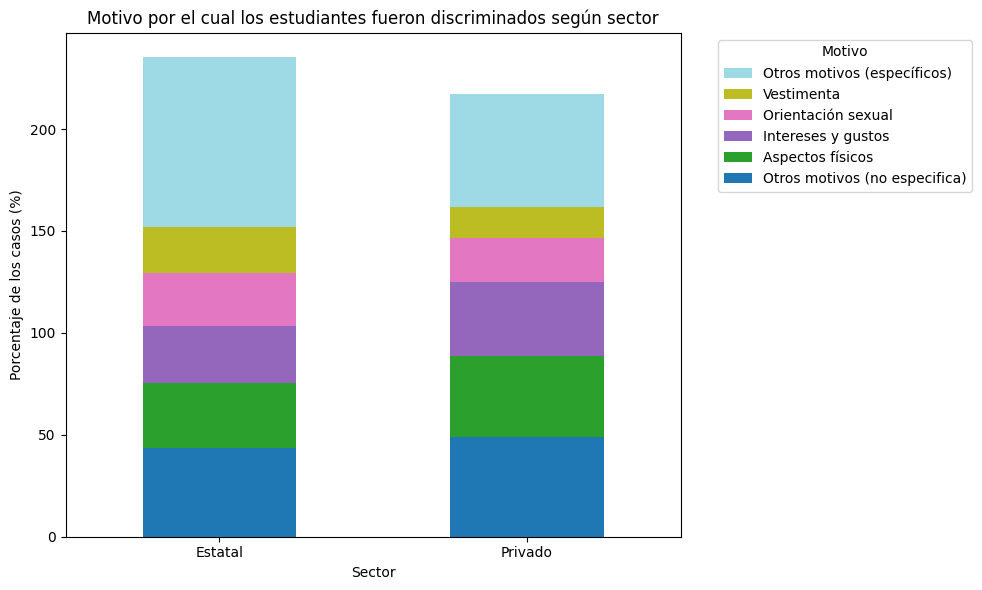

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter only rows where X happened ('1' as string or 1 as int)
df_x = df[df['apA37'].astype(str) == '1']

# Map sector codes to labels
sector_map = {'1': 'Estatal', '2': 'Privado', 1: 'Estatal', 2: 'Privado'}
df_x['sector_label'] = df_x['sector'].map(sector_map)

# Top 5 reasons
top5_reasons = ['apA38k','apA38g','apA38f','apA38a','apA38h']

# All reason columns
all_reason_cols = [col for col in df.columns if col.startswith('apA38')]
other_cols = [col for col in all_reason_cols if col not in top5_reasons]

# Map codes to labels
label_map = {
    'apA38a': 'Orientación sexual',
    'apA38b': 'Lugar de nacimiento',
    'apA38c': 'Pertenencia a un pueblo indígena',
    'apA38d': 'Discapacidad',
    'apA38e': 'Religión',
    'apA38f': 'Intereses y gustos',
    'apA38g': 'Aspectos físicos',
    'apA38h': 'Vestimenta',
    'apA38i': 'Calificaciones',
    'apA38j': 'Situación socioeconómica',
    'apA38k': 'Otros motivos (no especifica)'
}

# Count 1s robustly
def count_ones(df, cols):
    return df[cols].apply(lambda g: g.eq('1') | g.eq(1) | g.eq(1.0)).sum()

# Compute percentages per sector
sector_groups = []
for sector in df_x['sector_label'].unique():
    df_sector = df_x[df_x['sector_label'] == sector]
    
    counts_top5 = count_ones(df_sector, top5_reasons)
    counts_other = count_ones(df_sector, other_cols).sum()
    
    counts = counts_top5.copy()
    counts['Otros motivos (específicos)'] = counts_other
    
    counts = counts / len(df_sector) * 100
    sector_groups.append(counts)

# Combine into DataFrame
stacked_df = pd.DataFrame(sector_groups, index=df_x['sector_label'].unique())

# Rename columns for human-readable labels for the top 5 reasons
stacked_df = stacked_df.rename(columns={col: label_map.get(col, col) for col in stacked_df.columns})

# Plot stacked barplot
ax = stacked_df.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')

# Fix legend order to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='Motivo', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Motivo por el cual los estudiantes fueron discriminados según sector')
plt.ylabel('Porcentaje de los casos (%)')
plt.xlabel('Sector')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


C:\Users\loloa\AppData\Local\Temp\ipykernel_11528\275413787.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_x['sector_label'] = df_x['sector'].map(sector_map)


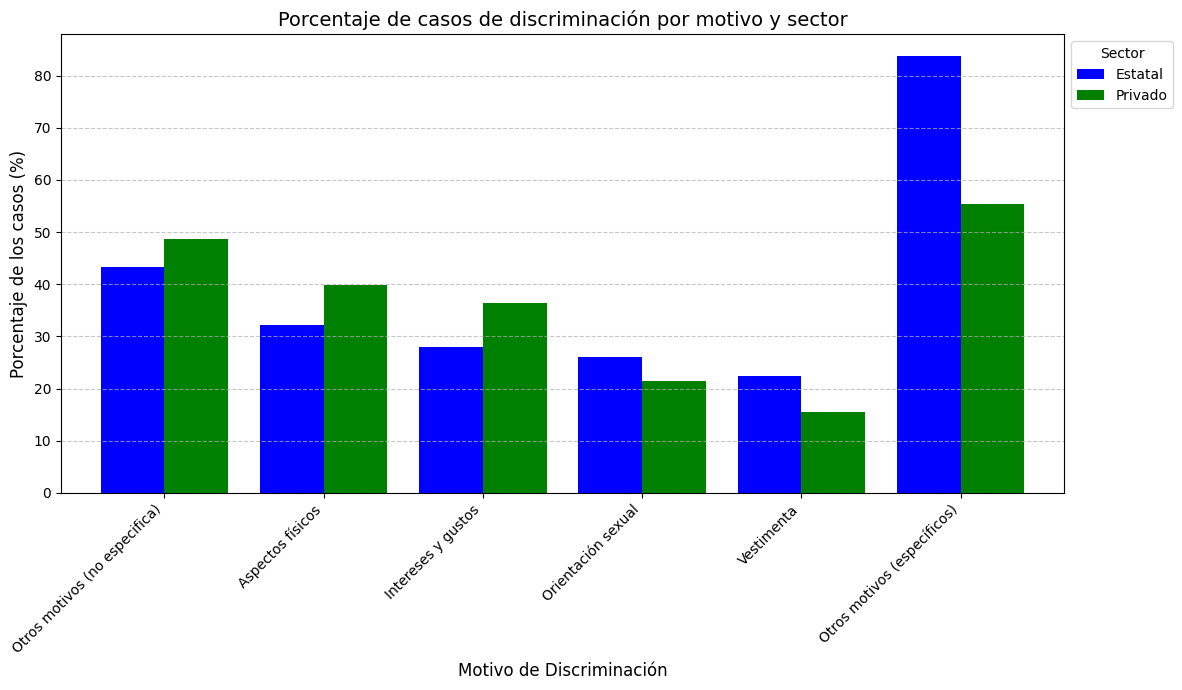

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# --- NOTE: Replace '...' with your actual data loading step if needed ---
# For example: df = pd.read_csv('your_data_file.csv')
# Assuming 'df' is available from a prior step

# Filter only rows where X happened ('1' as string or 1 as int)
df_x = df[df['apA37'].astype(str) == '1']

# Map sector codes to labels
sector_map = {'1': 'Estatal', '2': 'Privado', 1: 'Estatal', 2: 'Privado'}
df_x['sector_label'] = df_x['sector'].map(sector_map)

# Top 5 reasons - Note: These categories include the 'Otros motivos (no especifica)'
top5_reasons = ['apA38k','apA38g','apA38f','apA38a','apA38h']

# All reason columns
all_reason_cols = [col for col in df.columns if col.startswith('apA38')]
other_cols = [col for col in all_reason_cols if col not in top5_reasons]

# Map codes to labels
label_map = {
    'apA38a': 'Orientación sexual',
    'apA38b': 'Lugar de nacimiento',
    'apA38c': 'Pertenencia a un pueblo indígena',
    'apA38d': 'Discapacidad',
    'apA38e': 'Religión',
    'apA38f': 'Intereses y gustos',
    'apA38g': 'Aspectos físicos',
    'apA38h': 'Vestimenta',
    'apA38i': 'Calificaciones',
    'apA38j': 'Situación socioeconómica',
    'apA38k': 'Otros motivos (no especifica)'
}

# Count 1s robustly
def count_ones(df, cols):
    return df[cols].apply(lambda g: g.eq('1') | g.eq(1) | g.eq(1.0)).sum()

# Compute percentages per sector
sector_groups = []
for sector in df_x['sector_label'].unique():
    df_sector = df_x[df_x['sector_label'] == sector]
    
    counts_top5 = count_ones(df_sector, top5_reasons)
    counts_other = count_ones(df_sector, other_cols).sum()
    
    counts = counts_top5.copy()
    counts['Otros motivos (específicos)'] = counts_other
    
    counts = counts / len(df_sector) * 100
    sector_groups.append(counts)

# Combine into DataFrame: Index=Sector, Columns=Reasons
stacked_df = pd.DataFrame(sector_groups, index=df_x['sector_label'].unique())

# Rename columns for human-readable labels
stacked_df = stacked_df.rename(columns={col: label_map.get(col, col) for col in stacked_df.columns})

# Transpose the DataFrame: Index=Reasons, Columns=Sector (Estatal, Privado)
grouped_df = stacked_df.T

# Plot grouped bar chart with specified colors
ax = grouped_df.plot(
    kind='bar', 
    figsize=(12, 7), 
    # Color list is applied to the columns: Estatal (blue), Privado (green)
    color=['blue', 'green'], 
    width=0.8
)

# Set labels and title
plt.title('Porcentaje de casos de discriminación por motivo y sector', fontsize=14)
plt.ylabel('Porcentaje de los casos (%)', fontsize=12)
plt.xlabel('Motivo de Discriminación', fontsize=12)

# Rotate x-axis labels for better readability of reason names
plt.xticks(rotation=45, ha='right')

# Adjust legend - it now shows the sectors ('Estatal' and 'Privado')
ax.legend(title='Sector', bbox_to_anchor=(1.0, 1), loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
#plt.savefig('grouped_discrimination_chart_custom_colors.png')
# plt.show()

In [29]:
#variable con provincias= "jurisdiccion"

In [30]:
!pip install geopandas folium pandas unidecode matplotlib


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\loloa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [31]:
import geopandas as gpd
import pandas as pd
import json
from shapely import geometry

# Load your CSV (update the path if needed)
gdf_raw = pd.read_csv("C:/Users/loloa/OneDrive/Escritorio/facu/Ciencia de datos/trabajo_final/TP-Final-Ciencia-de-Datos/Provincias (2010).csv")

# Convert the JSON string in "Geometría en GeoJSON" to actual geometry objects
gdf_raw["geometry"] = gdf_raw["Geometría en GeoJSON"].apply(lambda x: geometry.shape(json.loads(x)))

# Build a proper GeoDataFrame
gdf = gpd.GeoDataFrame(
    gdf_raw,
    geometry="geometry",
    crs="EPSG:4326"  # geographic coordinates (lat/lon)
)

# Check that it worked
gdf.head()

,Código,Nombre,Superficie en km2,Latitud del centroide,Longitud del centroide,Geometría en GeoJSON,geometry
0,2,Ciudad Autónoma de Buenos Aires,203.871137,-34.614509,-58.446392,"{""type"":""Polygon"",""coordinates"":[[[-58.456478,...","POLYGON ((-58.45648 -34.5276, -58.45644 -34.52..."
1,6,Buenos Aires,306243.344561,-36.680986,-60.559733,"{""type"":""MultiPolygon"",""coordinates"":[[[[-58.4...","MULTIPOLYGON (((-58.44432 -34.33015, -58.44376..."
2,10,Catamarca,104981.399690,-27.376650,-66.908882,"{""type"":""Polygon"",""coordinates"":[[[-68.346699,...","POLYGON ((-68.3467 -25.17716, -68.26874 -25.19..."
3,14,Córdoba,165300.557002,-32.139833,-63.798645,"{""type"":""Polygon"",""coordinates"":[[[-63.917498,...","POLYGON ((-63.9175 -29.61625, -63.91658 -29.61..."
4,18,Corrientes,89396.358824,-28.771516,-57.799545,"{""type"":""Polygon"",""coordinates"":[[[-58.145832,...","POLYGON ((-58.14583 -27.27144, -58.13835 -27.2..."


In [32]:

gdf["Nombre"] = [
    "Ciudad Autónoma de Buenos Aires", "Buenos Aires", "Catamarca", "Córdoba", "Corrientes", 
    "Chaco", "Chubut", "Entre Ríos", "Formosa", "Jujuy", "La Pampa", "La Rioja", "Mendoza", 
    "Misiones", "Neuquén", "Río Negro", "Salta", "San Juan", "San Luis", "Santa Cruz", 
    "Santa Fe", "Santiago del Estero", "Tucumán", "Tierra del Fuego"
]

print(gdf["Nombre"])

0     Ciudad Autónoma de Buenos Aires
1                        Buenos Aires
2                           Catamarca
3                             Córdoba
4                          Corrientes
5                               Chaco
6                              Chubut
7                          Entre Ríos
8                             Formosa
9                               Jujuy
10                           La Pampa
11                           La Rioja
12                            Mendoza
13                           Misiones
14                            Neuquén
15                          Río Negro
16                              Salta
17                           San Juan
18                           San Luis
19                         Santa Cruz
20                           Santa Fe
21                Santiago del Estero
22                            Tucumán
23                   Tierra del Fuego
Name: Nombre, dtype: object


In [33]:
gdf = gdf.rename(columns={"Nombre": "jurisdiccion"})

In [34]:
# Crear variable con columnas 'jurisdiccion' y 'ap23'
promediof = df[['jurisdiccion', 'ap23']]
# Inspeccionar tipo y valores en 'ap23'
col = promediof["ap23"]
print("pandas dtype:", col.dtype)
print("nulos:", col.isna().sum())
print("\nTipos Python presentes (ej.: int, str, etc.):")
print(col.dropna().map(type).value_counts())
print("\nValores únicos (hasta 50):")
print(pd.Series(col.unique()).head(50))
print("\nFrecuencias (incluye NaN):")
print(col.value_counts(dropna=False).sort_index())

pandas dtype: object
nulos: 0

Tipos Python presentes (ej.: int, str, etc.):
ap23
<class 'str'>    642006
Name: count, dtype: int64

Valores únicos (hasta 50):
0     2
1    -9
2     1
3     3
4     4
5     5
6     6
7    -6
8      
9    -8
dtype: object

Frecuencias (incluye NaN):
ap23
        7669
-6      4965
-8       477
-9     48402
1      67996
2     223747
3     113684
4      83426
5      42005
6      49635
Name: count, dtype: int64


In [35]:
valid_values = {"1", "2", "3", "4", "5", "6"}
promediof = promediof[promediof['ap23'].isin(valid_values)]
print(promediof["ap23"].unique())

['2' '1' '3' '4' '5' '6']


In [36]:
# calcular incidencia: % de filas con ap23 == 5 o 6 por jurisdiccion
incidenciaf = (
    promediof
    .assign(ap23_num = pd.to_numeric(promediof['ap23'], errors='coerce'))
    .groupby('jurisdiccion')['ap23_num']
    .apply(lambda s: s.isin([5, 6]).mean() * 100)
    .reset_index(name='incidencia_percent')
)

# opcional: redondear a 1 decimal
incidenciaf['incidencia_percent'] = incidenciaf['incidencia_percent'].round(1)

print(incidenciaf)

    jurisdiccion  incidencia_percent
0              2                16.2
1              6                21.9
2             10                 9.0
3             14                12.3
4             18                 8.7
5             22                15.6
6             26                18.5
7             30                11.2
8             34                15.3
9             38                 5.6
10            42                14.0
11            46                10.7
12            50                12.2
13            54                11.0
14            58                12.8
15            62                17.2
16            66                 9.6
17            70                 5.6
18            74                10.7
19            78                16.1
20            82                12.6
21            86                 8.3
22            90                10.9
23            94                17.4


In [37]:
# Replace numeric 'jurisdiccion' codes in incidenciaf with province names
# and rename the column to 'Provincia'

mapping = {
    2: "Ciudad Autónoma de Buenos Aires",
    6: "Buenos Aires",
    10: "Catamarca",
    14: "Córdoba",
    18: "Corrientes",
    22: "Chaco",
    26: "Chubut",
    30: "Entre Ríos",
    34: "Formosa",
    38: "Jujuy",
    42: "La Pampa",
    46: "La Rioja",
    50: "Mendoza",
    54: "Misiones",
    58: "Neuquén",
    62: "Río Negro",
    66: "Salta",
    70: "San Juan",
    74: "San Luis",
    78: "Santa Cruz",
    82: "Santa Fe",
    86: "Santiago del Estero",
    90: "Tucumán",
    94: "Tierra del Fuego"
}

incidenciaf["jurisdiccion"] = incidenciaf["jurisdiccion"].replace(mapping)



In [38]:
from unidecode import unidecode

In [39]:
# --- Merge and plot ---
import folium
import json

# Ensure text matches between dataframes
gdf["jurisdiccion"] = gdf["jurisdiccion"].apply(lambda x: unidecode(str(x)).strip().lower())
incidenciaf["jurisdiccion"] = incidenciaf["jurisdiccion"].apply(lambda x: unidecode(str(x)).strip().lower())

# Merge on 'jurisdiccion'
merged = gdf.merge(incidenciaf, on="jurisdiccion", how="left")

# Convert merged GeoDataFrame to GeoJSON dictionary
geo_json_data = json.loads(merged.to_json())

# Create base map centered on Argentina
m = folium.Map(location=[-38.4, -63.6], zoom_start=4)

# Add choropleth (color-coded heatmap)
folium.Choropleth(
    geo_data=geo_json_data,
    name="Porcentaje de faltantes seriales (16<)",
    data=merged,
    columns=["jurisdiccion", "incidencia_percent"],
    key_on="feature.properties.jurisdiccion",
    fill_color="YlOrRd",  # Yellow → Orange → Red gradient
    fill_opacity=0.8,
    line_opacity=0.3,
    legend_name="Porcentaje de faltantes seriales (16<)",
).add_to(m)

# Add hover tooltip (province name + percentage)
folium.GeoJson(
    geo_json_data,
    name="Provincias",
    tooltip=folium.features.GeoJsonTooltip(
        fields=["jurisdiccion", "incidencia_percent"],
        aliases=["Provincia:", "Porcentaje de faltantes seriales"],
        localize=True,
        style="""
            background-color: white;    /* solid background */
            border: 2px solid black;    /* border */
            border-radius: 5px;         /* rounded corners */
            box-shadow: 3px 3px 6px rgba(0,0,0,0.3); /* subtle shadow */
            font-size: 14px;            /* bigger text */
            font-weight: bold;
            padding: 6px 8px;           /* spacing around text */
        """
    )
).add_to(m)

# Display interactive map
# Add percentage labels on top of each province
for idx, row in merged.iterrows():
    # Get centroid coordinates
    centroid = row['geometry'].centroid
    lat, lon = centroid.y, centroid.x
    
    # Add text marker
    folium.map.Marker(
        [lat, lon],
        icon=folium.DivIcon(
            html=f"""<div style="font-size: 12px; font-weight: bold; color: black">
                     {row['incidencia_percent']}%</div>"""
        )
    ).add_to(m)

# Display map again


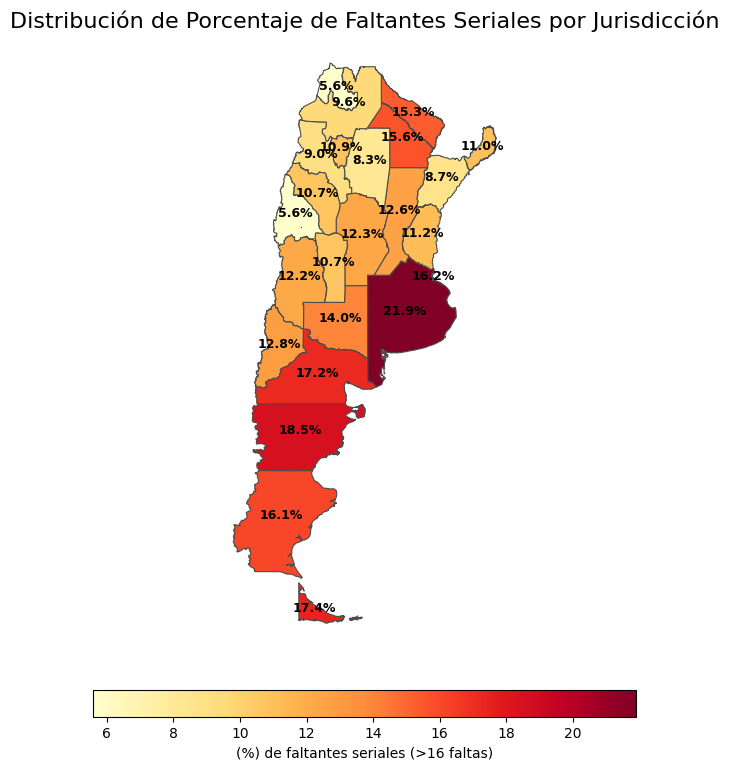

In [40]:
# --- Static Map (Image) using Matplotlib/GeoPandas ---
import matplotlib.pyplot as plt

# The previous data preparation steps remain:
# import pandas as pd
# import geopandas as gpd
# from unidecode import unidecode
# ... (data loading for gdf and incidenciaf) ...
# gdf["jurisdiccion"] = gdf["jurisdiccion"].apply(lambda x: unidecode(str(x)).strip().lower())
# incidenciaf["jurisdiccion"] = incidenciaf["jurisdiccion"].apply(lambda x: unidecode(str(x)).strip().lower())
# merged = gdf.merge(incidenciaf, on="jurisdiccion", how="left")


# 1. Create the plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# 2. Plot the choropleth map
merged.plot(
    column="incidencia_percent",
    cmap="YlOrRd",  # Yellow → Orange → Red gradient, same as in folium
    linewidth=0.8,
    ax=ax,
    edgecolor="0.3", # Darker lines for province borders
    legend=True,
    legend_kwds={
        "label": "(%) de faltantes seriales (>16 faltas)",
        "orientation": "horizontal",
        "pad": 0.05,
        "shrink": 0.7,
    },
    missing_kwds={"color": "lightgrey", "label": "No Data"}, # Handle provinces with no data
)

# 3. Add percentage labels on top of each province (for legibility)
# Loop through the merged GeoDataFrame to calculate centroid and add label
for idx, row in merged.iterrows():
    # Ensure incidence is not None/NaN before attempting to label
    if not pd.isna(row["incidencia_percent"]):
        # Calculate centroid (approximate center) for label placement
        centroid = row["geometry"].centroid
        
        # Format the percentage value for the label
        label = f"{row['incidencia_percent']:.1f}%" # Format to 1 decimal place, or use f"{int(row['incidencia_percent'])}%" if you prefer integers
        
        # Add the text label to the map
        ax.annotate(
            text=label,
            xy=(centroid.x, centroid.y),
            horizontalalignment="center",
            fontsize=9,
            color="black", # Black text is usually more legible
            fontweight='bold',
            # Adjusting vertical alignment might be needed for specific geometries
            # va='center'
        )

# 4. Set plot title and remove axis for a clean map look
ax.set_title(
    "Distribución de Porcentaje de Faltantes Seriales por Jurisdicción",
    fontdict={"fontsize": "16", "fontweight": "3"},
)
ax.set_axis_off()

# 5. Display the map image
plt.show()

# Optional: Save the map to a file (e.g., PNG)
# plt.savefig("static_choropleth_map.png", dpi=300)

In [41]:
import pandas as pd
from unidecode import unidecode

# --- 1. Calcular las nuevas métricas desde el DataFrame 'df' ---

df_calculos = df.copy()

# Convertir columnas a numérico
df_calculos['mpuntaje_num'] = pd.to_numeric(df_calculos['mpuntaje'], errors='coerce')
df_calculos['lpuntaje_num'] = pd.to_numeric(df_calculos['lpuntaje'], errors='coerce')

# Calcular indicadores
df_calculos['es_discriminado'] = df_calculos['apA37'].astype(str) == '1'
df_calculos['es_repetidor'] = df_calculos['ap22'].astype(str).isin(['2', '3', '4'])

# Agrupar por jurisdiccion (los IDs numéricos) y agregar
metricas_agg = df_calculos.groupby('jurisdiccion').agg(
    perc_discriminacion=pd.NamedAgg(column='es_discriminado', aggfunc='mean'),
    perc_repetidores=pd.NamedAgg(column='es_repetidor', aggfunc='mean'),
    avg_matematicas=pd.NamedAgg(column='mpuntaje_num', aggfunc='mean'),
    avg_lengua=pd.NamedAgg(column='lpuntaje_num', aggfunc='mean')
).reset_index()

# Convertir proporciones y redondear
metricas_agg['perc_discriminacion'] = (metricas_agg['perc_discriminacion'] * 100).round(1)
metricas_agg['perc_repetidores'] = (metricas_agg['perc_repetidores'] * 100).round(1)

# --- SECCIÓN DE RANKING (MODIFICADA) ---
# Contamos el total de jurisdicciones para el ranking (ej. "3/24")
total_provincias = len(metricas_agg)

# Creamos columnas de ranking (aseguramos que sea 'int' con .astype(int))
metricas_agg['rank_mat'] = metricas_agg['avg_matematicas'].rank(ascending=False, method='min').astype(int)
metricas_agg['rank_len'] = metricas_agg['avg_lengua'].rank(ascending=False, method='min').astype(int)

# --- ¡CAMBIO EN LA CREACIÓN DE TEXTO! ---
# Creamos las nuevas columnas de TEXTO para el tooltip
# Formato: "X/24" (SOLO el valor del ranking)
metricas_agg['avg_matematicas_str'] = metricas_agg.apply(
    lambda row: f"{row['rank_mat']}/{total_provincias}", axis=1
)
metricas_agg['avg_lengua_str'] = metricas_agg.apply(
    lambda row: f"{row['rank_len']}/{total_provincias}", axis=1
)
metricas_agg['avg_matematicas_str'] = metricas_agg.apply(
    lambda row: f"{int(row['rank_mat'])}/{total_provincias}", axis=1
)
metricas_agg['avg_lengua_str'] = metricas_agg.apply(
    lambda row: f"{int(row['rank_len'])}/{total_provincias}", axis=1
)


print("--- Métricas adicionales calculadas (Solo Valor Ranking) ---")
# Mostramos las nuevas columnas de texto
print(metricas_agg[['jurisdiccion', 'avg_matematicas_str', 'avg_lengua_str']].head())

--- Métricas adicionales calculadas (Solo Valor Ranking) ---
   jurisdiccion avg_matematicas_str avg_lengua_str
0             2                1/24           1/24
1             6                6/24           7/24
2            10               23/24          22/24
3            14                2/24           2/24
4            18               16/24          18/24


In [42]:
# --- 2. Limpiar 'jurisdiccion' en las nuevas métricas ---
#    (Usando el 'mapping' y 'unidecode' que definiste antes)

# Aplicar el mapeo de ID numérico a nombre de provincia
metricas_agg["jurisdiccion"] = metricas_agg["jurisdiccion"].replace(mapping)

# Aplicar la misma limpieza de texto que en el código original
metricas_agg["jurisdiccion"] = metricas_agg["jurisdiccion"].apply(lambda x: unidecode(str(x)).strip().lower())

print("\n--- Métricas adicionales (con 'jurisdiccion' limpiado) ---")
print(metricas_agg.head())


# --- 3. Unir las nuevas métricas al GeoDataFrame 'merged' ---

# 'merged' ya existe de tu celda anterior (gdf.merge(incidenciaf))
# 'metricas_agg' tiene la 'jurisdiccion' limpia, lista para unirse
# Creamos 'merged_total' con toda la información
merged_total = merged.merge(metricas_agg, on="jurisdiccion", how="left")

print("\n--- GeoDataFrame final (merged_total) ---")
# Mostramos las columnas, incluyendo las nuevas
print(merged_total[['jurisdiccion', 'incidencia_percent', 'perc_discriminacion', 'perc_repetidores', 'avg_matematicas', 'avg_lengua']].head())


--- Métricas adicionales (con 'jurisdiccion' limpiado) ---
                      jurisdiccion  perc_discriminacion  perc_repetidores  \
0  ciudad autonoma de buenos aires                 10.9              10.6   
1                     buenos aires                 14.0              13.5   
2                        catamarca                 17.4              12.2   
3                          cordoba                 14.0               6.2   
4                       corrientes                 18.4              23.5   

   avg_matematicas  avg_lengua  rank_mat  rank_len avg_matematicas_str  \
0       516.668494  535.435993         1         1                1/24   
1       476.061251  499.084968         6         7                6/24   
2       453.039127  481.017768        23        22               23/24   
3       500.431624  518.341467         2         2                2/24   
4       467.891923  487.335859        16        18               16/24   

  avg_lengua_str  
0           1

In [43]:
# --- 4. Crear el nuevo mapa con el tooltip actualizado ---
import folium
import json

# Capitalizamos la columna 'jurisdiccion' para que se vea bien en el tooltip
merged_total['jurisdiccion'] = merged_total['jurisdiccion'].str.capitalize()

# Convertir el GeoDataFrame 'merged_total' a GeoJSON
geo_json_data_actualizado = json.loads(merged_total.to_json())

# Crear mapa base
m_actualizado = folium.Map(location=[-38.4, -63.6], zoom_start=4)

# Añadir Choropleth
folium.Choropleth(
    geo_data=geo_json_data_actualizado,
    name="Porcentaje de faltantes seriales (16<)",
    data=merged_total,
    columns=["jurisdiccion", "incidencia_percent"],
    key_on="feature.properties.jurisdiccion", 
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.3,
    legend_name="Porcentaje de faltantes seriales (16<)",
).add_to(m_actualizado)

# --- ¡AQUÍ ESTÁ EL CAMBIO (EN 'aliases')! ---
# Añadir el GeoJson con el Tooltip actualizado
folium.GeoJson(
    geo_json_data_actualizado,
    name="Provincias",
    tooltip=folium.features.GeoJsonTooltip(
        fields=[
            "jurisdiccion", 
            "incidencia_percent",
            "perc_discriminacion",
            "perc_repetidores",
            "avg_matematicas_str",  # Columna solo con "Rank: X/24"
            "avg_lengua_str"        # Columna solo con "Rank: X/24"
        ],
        aliases=[
            "Provincia:", 
            "% faltantes seriales:",
            "% sufren discriminación:",
            "% repetidores:",
            "Ranking desempeño matemáticas:",    # <-- Etiqueta cambiada
            "Ranking desempeño lengua:"          # <-- Etiqueta cambiada
        ],
        localize=True,
        style="""
            background-color: white;
            border: 2px solid black;
            border-radius: 5px;
            box-shadow: 3px 3px 6px rgba(0,0,0,0.3);
            font-size: 14px;
            font-weight: bold;
            padding: 6px 8px;
        """
    )
).add_to(m_actualizado)

# Añadir las etiquetas de porcentaje
for idx, row in merged_total.iterrows():
    if row['geometry'] and not row['geometry'].is_empty:
        centroid = row['geometry'].centroid
        lat, lon = centroid.y, centroid.x
        
        folium.map.Marker(
            [lat, lon],
            icon=folium.DivIcon(
                html=f"""<div style="font-size: 12px; font-weight: bold; color: black">
                         {row['incidencia_percent']}%</div>"""
            )
        ).add_to(m_actualizado)

# --- 5. Mostrar el nuevo mapa ---


El mapa de correlación se ha generado y codificado en Base64.


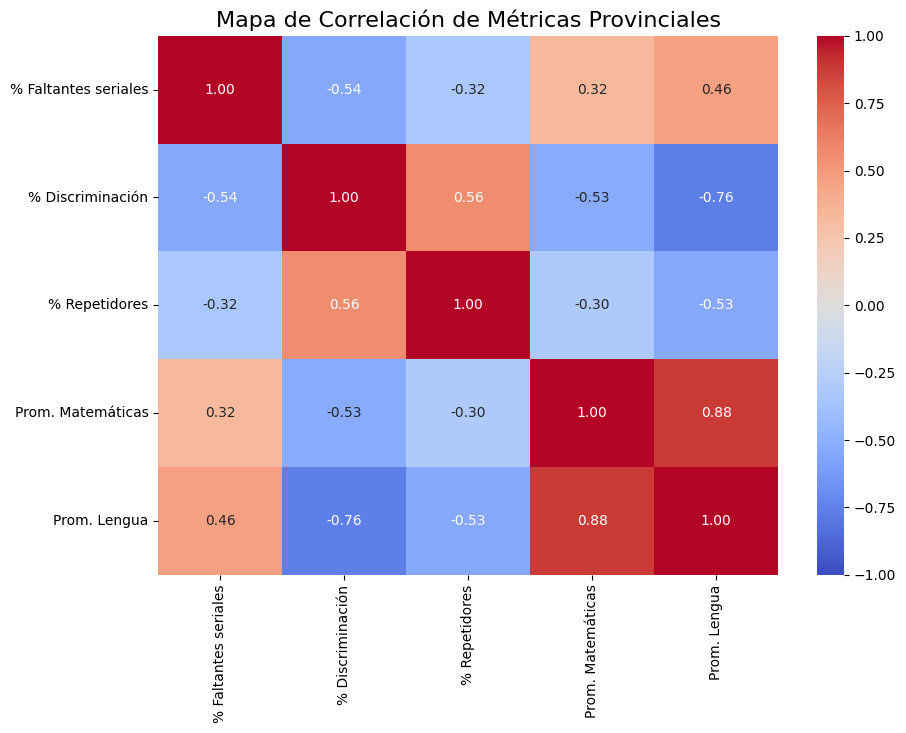

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
import io
import base64

# --- 1. Preparar los datos (igual que antes) ---
# Asume que 'incidenciaf' y 'metricas_agg' ya existen
datos_corr = incidenciaf.merge(metricas_agg, on="jurisdiccion", how="inner")

columnas_para_corr = [
    'incidencia_percent',
    'perc_discriminacion',
    'perc_repetidores',
    'avg_matematicas',  # Usamos la métrica numérica, no el string
    'avg_lengua'        # Usamos la mética numérica, no el string
]

df_para_corr = datos_corr[columnas_para_corr]

# Renombrar columnas para un gráfico más limpio
df_para_corr.columns = [
    '% Faltantes seriales',
    '% Discriminación',
    '% Repetidores',
    'Prom. Matemáticas',
    'Prom. Lengua'
]

matriz_corr = df_para_corr.corr()

# --- 2. Graficar el heatmap (sin mostrarlo con plt.show()) ---
# Creamos la figura y el eje (ax)
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    matriz_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1,
    ax=ax  # Le decimos a seaborn que use este eje
)
ax.set_title('Mapa de Correlación de Métricas Provinciales', fontsize=16)

# --- 3. Guardar el gráfico en un buffer en memoria ---
img_buffer = io.BytesIO()
#fig.savefig(img_buffer, format='png', bbox_inches='tight') # bbox_inches='tight' para que no se corte
img_buffer.seek(0) # Rebobinamos el buffer

# --- 4. Codificar la imagen en Base64 ---
# Esto convierte la imagen PNG en un string de texto
base64_string = base64.b64encode(img_buffer.read()).decode('utf-8')

# Cerramos la figura para liberar memoria
plt.close(fig)

print("El mapa de correlación se ha generado y codificado en Base64.")

# Opcional: Mostrar el gráfico en el notebook para verificar
# (Esto muestra el mismo 'fig' que acabamos de guardar)
display(fig)

In [45]:
# --- 5. Agregar el mapa de correlación al mapa interactivo ---

# Crear el contenido HTML para el popup (sin cambios)
html_popup = f'<img src="data:image/png;base64,{base64_string}" alt="Mapa de Correlación" style="width:500px; height:auto;">'
popup = folium.Popup(html_popup, max_width=530)

# --- ¡CAMBIOS AQUÍ! ---

# Nueva ubicación del marcador: más a la derecha (longitud menos negativa)
# Ej: Antes era -58.0, ahora lo movemos a -52.0
folium.Marker(
    location=[-40.0, -52.0], # Ajusta la longitud para moverlo horizontalmente
    tooltip="Clic para ver el Mapa de Correlación",
    icon=folium.Icon(
        color="blue",
        icon="info-sign",
        prefix='glyphicon', # O 'fa' si prefieres, para tener más control CSS
        # Inyectamos CSS personalizado para hacer el botón más grande
        # Esto hace el ícono (y, por lo tanto, el botón) visiblemente más grande
        html='<div style="font-size: 24px; padding: 5px;"><i class="glyphicon glyphicon-info-sign"></i></div>'
    ),
    popup=popup
).add_to(m_actualizado)

# --- FIN DE LOS CAMBIOS ---

# --- 6. Mostrar el mapa finalizado ---
#m_actualizado

In [46]:
#m_actualizado.save("C:\\Users\\loloa\\OneDrive\\Escritorio\\facu\\Ciencia de datos\\trabajo_final\\TP-Final-Ciencia-de-Datos\\mapa_interactivo.html")

In [47]:
df['ap01'] = pd.to_numeric(df['ap01'], errors='coerce')
df["ap23"]=pd.to_numeric(df["ap23"],errors="coerce")

In [48]:
print(df["edadA_junio2023"].min())
print(df["edadA_junio2023"].max())


-9
5


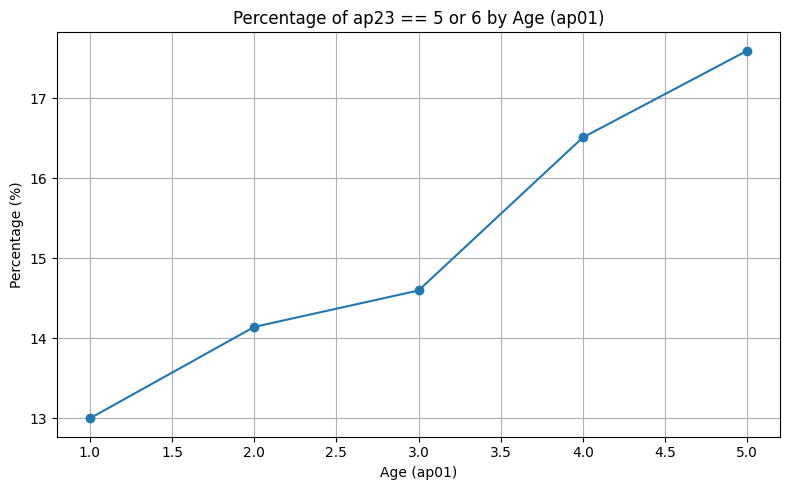

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate the percentage of ap23 values that are 5 or 6 for each age (ap01)
percentage_by_age = (
    df.groupby('ap01')['ap23']
    .apply(lambda x: (x.isin([5, 6]).mean()) * 100)
    .reset_index(name='percentage')
)

# Plot the line chart
plt.figure(figsize=(8, 5))
plt.plot(percentage_by_age['ap01'], percentage_by_age['percentage'], marker='o')
plt.title('Percentage of ap23 == 5 or 6 by Age (ap01)')
plt.xlabel('Age (ap01)')
plt.ylabel('Percentage (%)')
plt.grid(True)
plt.tight_layout()
plt.show()


In [50]:
print(df.head())

           ï»¿ID1  jurisdiccion  seccion  idalumno  sector  ambito  ap01 ap02  \
0  20004002000400            50        1    247287       1       2   2.0    1   
1  20004002000400            50        2    247266       1       2   3.0    9   
2  20004002000400            50        1    247288       1       2   3.0    9   
3  20004002000400            50        1    247289       1       2   2.0    1   
4  20004002000400            50        1    247290       1       2   2.0   12   

  ap03 ap04  ...   mpuntaje  NSE_puntaje NSE_nivel edadA_junio2023 migracion  \
0    1    1  ...  466.75851  ,0057786424         2               2         2   
1    1    1  ...  455.46713   -,36903167         2               2         2   
2    1    1  ...  356.53931   -,50107211         2               2         2   
3    1    1  ...  449.15985    ,59687847         2               2         2   
4    1    1  ...  444.71057    ,92589754         2               2         2   

  sobreedad Nivel_Ed_Madre Nivel

In [51]:
print(df["ap23"].unique())
print(df["NSE_nivel"].unique())

[ 2. -9.  1.  3.  4.  5.  6. -6. nan -8.]
[2 3 1]


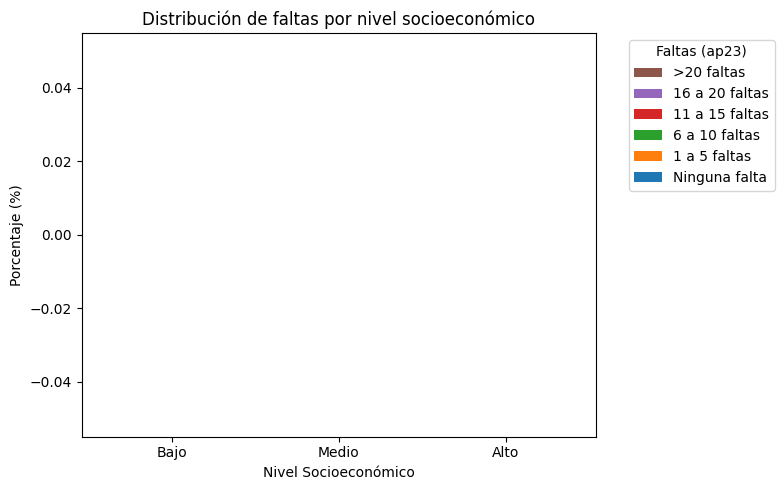

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# --- mappings / order ---
ap23_labels = {
    1: 'Ninguna falta',
    2: '1 a 5 faltas',
    3: '6 a 10 faltas',
    4: '11 a 15 faltas',
    5: '16 a 20 faltas',
    6: '>20 faltas'
}
ap23_order = [ap23_labels[i] for i in range(1, 7)]
nse_order = ['Bajo', 'Medio', 'Alto']

# --- clean and prep data ---
df = df.copy()
df['ap23_num'] = pd.to_numeric(df['ap23'], errors='coerce')
df = df[df['ap23_num'].between(1, 6)]
df['ap23_int'] = df['ap23_num'].astype(int)
df['ap23_label'] = df['ap23_int'].map(ap23_labels)
df['NSE_nivel'] = df['NSE_nivel'].astype(str).str.strip()

# --- compute percentages ---
grouped = (
    df.groupby(['NSE_nivel', 'ap23_label'])
      .size()
      .rename('count')
      .reset_index()
)

pivot = grouped.pivot(index='NSE_nivel', columns='ap23_label', values='count').fillna(0)
pivot = pivot.reindex(index=nse_order, columns=ap23_order, fill_value=0)
percent_df = pivot.div(pivot.sum(axis=1).replace(0, 1), axis=0) * 100

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 5))
bottom = None
bars = []

# Plot in correct bottom-to-top order
for label in ap23_order:
    bar = ax.bar(
        percent_df.index,
        percent_df[label],
        bottom=bottom,
        label=label
    )
    bars.append(bar)
    if bottom is None:
        bottom = percent_df[label]
    else:
        bottom += percent_df[label]

# ✅ Legend fixed — now uses lists instead of iterators
ax.legend(
    list(reversed(bars)),
    list(reversed(ap23_order)),
    title='Faltas (ap23)',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

ax.set_xlabel('Nivel Socioeconómico')
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Distribución de faltas por nivel socioeconómico')

plt.tight_layout()
#plt.savefig("faltas_por_NSE.png", dpi=300, bbox_inches='tight')
plt.show()


In [55]:
import pandas as pd

# Define the specific values for filtering
CLIMA_VALUES = ['1', '2', '3']
AP23_VALUES = [1, 2, 3, 4, 5, 6]

# 1. Filter the DataFrame
# This step ensures we only keep rows where both 'clima_escolar' and 'ap23'
# contain one of the specified values.
df_filtered = df[
    df['clima_escolar'].isin(CLIMA_VALUES) &
    df['ap23'].isin(AP23_VALUES)
].copy()

# 2. Generate the cross-tabulation (contingency table)
# pd.crosstab is the most direct way to count occurrences of combinations.
# We set dropna=False to ensure the defined AP23_VALUES and CLIMA_VALUES
# are represented, even if they have zero counts after filtering.
# We use observed=True for categorical data to speed up grouping.
result_table = pd.crosstab(
    index=df_filtered['clima_escolar'], 
    columns=df_filtered['ap23']
).reindex(index=CLIMA_VALUES, columns=AP23_VALUES, fill_value=0)

print("## Counts of 'ap23' values for each 'clima_escolar'")
print(result_table)

## Counts of 'ap23' values for each 'clima_escolar'
ap23               1       2      3      4      5      6
clima_escolar                                           
1              14952   38980  19092  14543   7673  10477
2              42472  146832  75777  55676  27923  32126
3               9022   33252  16419  11459   5499   5899


## Relative Frequency Table (Row-wise Percentages):
ap23           No tiene faltas  1 a 5 faltas  6 a 10 faltas  11 a 15 faltas  \
clima_escolar                                                                 
Negativo             14.143421     36.872026      18.059536       13.756539   
Intermedio           11.153186     38.558216      19.899109       14.620568   
Positivo             11.063151     40.774985      20.133660       14.051502   

ap23           16 a 20 faltas  Más de 20 faltas  
clima_escolar                                    
Negativo             7.258057          9.910421  
Intermedio           7.332605          8.436317  
Positivo             6.743102          7.233599  

---
Grouped Bar Plot saved as 'clima_escolar_ap23_grouped_bar_proportions.png'


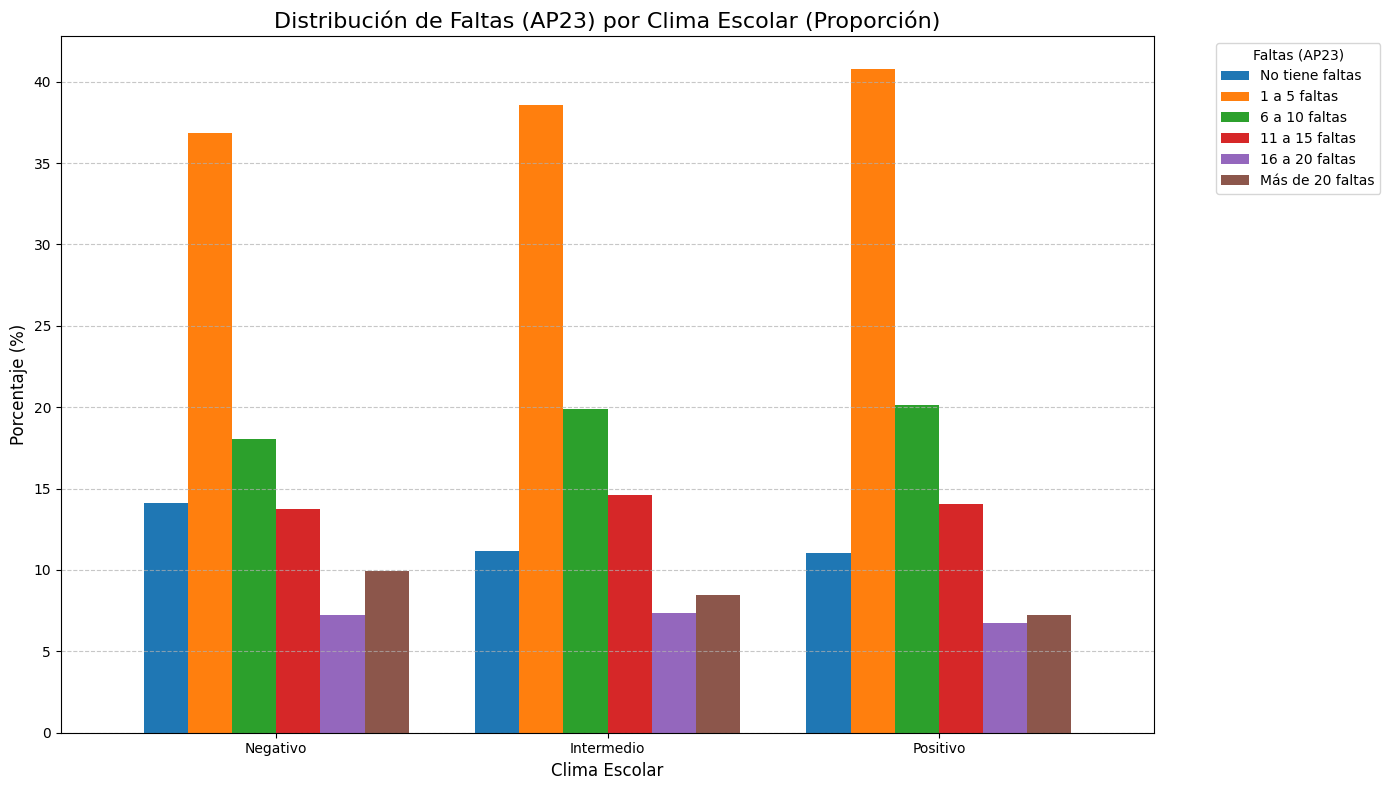

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ASSUMING 'df' IS YOUR EXISTING PANDAS DATAFRAME

# --- 1. Define Parameters and Labels ---

# Define the specific values to include
# 'ap23' are expected to be integers, 'clima_escolar' are expected to be strings
CLIMA_VALUES = ['1', '2', '3']
AP23_VALUES = [1, 2, 3, 4, 5, 6]

# Define the labels for the visualization
ap23_labels = {
    1: 'No tiene faltas',
    2: '1 a 5 faltas',
    3: '6 a 10 faltas',
    4: '11 a 15 faltas',
    5: '16 a 20 faltas',
    6: 'Más de 20 faltas'
}

clima_labels = {
    '1': 'Negativo',
    '2': 'Intermedio',
    '3': 'Positivo'
}

# --- 2. Filter Data and Create Relative Frequency Table ---

# Filter the DataFrame to include only the required values
df_filtered = df[
    df['clima_escolar'].isin(CLIMA_VALUES) &
    df['ap23'].isin(AP23_VALUES)
].copy()

# Create the cross-tabulation table (raw counts)
counts_table = pd.crosstab(
    index=df_filtered['clima_escolar'], 
    columns=df_filtered['ap23']
).reindex(index=CLIMA_VALUES, columns=AP23_VALUES, fill_value=0)

# Calculate the proportion of each ap23 value within each clima_escolar group (axis=1)
# Multiply by 100 to get a percentage
proportions_table = counts_table.apply(lambda x: x / x.sum(), axis=1) * 100

# Apply descriptive labels to the table axes for better visualization
proportions_table.index = proportions_table.index.map(clima_labels)
proportions_table.columns = proportions_table.columns.map(ap23_labels)

print("## Relative Frequency Table (Row-wise Percentages):")
print(proportions_table)
print("\n---")


# --- 3. Generate Grouped Bar Plot ---

# Plot the proportions table directly using the pandas plotting wrapper
fig, ax = plt.subplots(figsize=(14, 8))

proportions_table.plot(
    kind='bar', 
    ax=ax, 
    width=0.8,
    legend=True
)

plt.title('Distribución de Faltas por Clima Escolar (Proporción)', fontsize=16)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Clima Escolar', fontsize=12)
plt.xticks(rotation=0) # Keep X-labels horizontal

# Move legend outside the plot for better visibility
plt.legend(
    title='Faltas (AP23)',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# Add grid lines for easier comparison of bar heights
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('clima_escolar_ap23_grouped_bar_proportions.png')
print("Grouped Bar Plot saved as 'clima_escolar_ap23_grouped_bar_proportions.png'")